### MSC_DA_CA2

### Dataset - 1: THA25 - Passenger Journeys by Public Transport
        
https://data.gov.ie/dataset/tha25-passenger-journeys-by-public-transport
    
Published by: National Transport Authority
Licensed under: Creative Commons Attribution 4.0
Category: Transport   
    
Data Owner	Noreen Dorgan
Data Owner Email	transport@cso.ie
Data Owner Telephone	(+353) 21 453 5260
Theme	Transport
Date updated	2023-10-19
Language	English
Landing page	https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/THA25/JSON-stat/2.0/en
    
        ________________________________________////___________________________________________
        
### Dataset - 2 (Passenger Journeys by Luas)
TII03 - Passenger Journeys by Luas 

https://data.gov.ie/dataset/tii03-passenger-journeys-by-luas

Published by: Transport Infrastructure Ireland
Licensed under: Creative Commons Attribution 4.0
Category: Government

Data Owner	Noreen Dorgan
Data Owner Email	transport@cso.ie
Data Owner Telephone	(+353) 21 453 5260
Theme	Government
Date updated	2023-10-19
Language	English
Landing page	https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/TII03/JSON-stat/2.0/en

        

### Compare: Ireland (IRL)  with New Zealand (NZL), Finland (FIN) or Sweden, Denmark (DNK), Portugal (PRT). 

Ireland's transport infrastructure can be compared to those of other countries in a variety of ways. Here are a few nations that may provide useful comparisons with Ireland in terms of economic growth, size, geography, and urban-rural dynamics:

Consider aspects such as the extent and quality of road and rail networks, investment in public transport, policies towards sustainable transportation, and the difficulty of providing connectivity in both urban and rural areas when comparing Ireland's transport infrastructure to that of these countries. While these countries share certain qualities with Ireland, they also have distinct characteristics due to their varied geographical, economic, and historical circumstances.


### Dataset - 3: Infrastructure maintenance - Euro Area - 2000 - 2021

https://data.oecd.org/transport/infrastructure-maintenance.htm#indicator-chart

Infrastructure maintenance covers spending on preservation of the existing transport network. It only covers maintenance expenditure financed by public administrations. Efficient transport infrastructure provides economic and social benefits to both advanced and emerging economies by: improving market accessibility and productivity, ensuring balanced regional economic development, creating employment, promoting labour mobility and connecting communities. This indicator is measured in euros and shown as components for road, rail, total inland, air and sea components.

In [428]:
#Importing the essential libraries, which are Pandas, Matplotlib, Numpy, and Seaborn.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
from matplotlib import cm
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [429]:
#Command to display all columns in the file.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Dataset - 1 (Passenger Journeys by Public Transport - IRL)
        
https://data.gov.ie/dataset/tha25-passenger-journeys-by-public-transport
   

In [430]:
# Importing the Dataset 
public_transp_ie = pd.read_csv('passenger_publictransp_ie.csv')
public_transp_ie.head()

,STATISTIC,Statistic Label,TLIST(W1),Week,C03935V04687,Mode of Transport,UNIT,VALUE
0,THA25C01,Passenger Journeys,2019W01,2019 Week 01,10,Dublin Metro Bus,Number,1987891.0
1,THA25C01,Passenger Journeys,2019W01,2019 Week 01,20,"Bus, excluding Dublin Metro",Number,497598.0
2,THA25C01,Passenger Journeys,2019W01,2019 Week 01,30,Rail,Number,NaN
3,THA25C01,Passenger Journeys,2019W01,2019 Week 01,40,"All public transport, excluding LUAS",Number,2485489.0
4,THA25C01,Passenger Journeys,2019W02,2019 Week 02,10,Dublin Metro Bus,Number,2709579.0


In [431]:
public_transp_ie.shape

(1024, 8)

In [432]:
public_transp_ie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   STATISTIC          1024 non-null   object 
 1   Statistic Label    1024 non-null   object 
 2   TLIST(W1)          1024 non-null   object 
 3   Week               1024 non-null   object 
 4   C03935V04687       1024 non-null   int64  
 5   Mode of Transport  1024 non-null   object 
 6   UNIT               1024 non-null   object 
 7   VALUE              960 non-null    float64
dtypes: float64(1), int64(1), object(6)
memory usage: 64.1+ KB


In [433]:
public_transp_ie.isnull().sum()

STATISTIC             0
Statistic Label       0
TLIST(W1)             0
Week                  0
C03935V04687          0
Mode of Transport     0
UNIT                  0
VALUE                64
dtype: int64

In [434]:
# Displaying only rows with missing values in 'Value' column 
missing_value_rows = public_transp_ie[public_transp_ie['VALUE'].isnull()]
print(missing_value_rows)

    STATISTIC     Statistic Label TLIST(W1)          Week  C03935V04687  \
2    THA25C01  Passenger Journeys   2019W01  2019 Week 01            30   
6    THA25C01  Passenger Journeys   2019W02  2019 Week 02            30   
10   THA25C01  Passenger Journeys   2019W03  2019 Week 03            30   
14   THA25C01  Passenger Journeys   2019W04  2019 Week 04            30   
18   THA25C01  Passenger Journeys   2019W05  2019 Week 05            30   
22   THA25C01  Passenger Journeys   2019W06  2019 Week 06            30   
26   THA25C01  Passenger Journeys   2019W07  2019 Week 07            30   
30   THA25C01  Passenger Journeys   2019W08  2019 Week 08            30   
34   THA25C01  Passenger Journeys   2019W09  2019 Week 09            30   
38   THA25C01  Passenger Journeys   2019W10  2019 Week 10            30   
42   THA25C01  Passenger Journeys   2019W11  2019 Week 11            30   
46   THA25C01  Passenger Journeys   2019W12  2019 Week 12            30   
50   THA25C01  Passenger 

In [435]:
from datetime import datetime, timedelta

# Extract the year from the 'TLIST(W1)' column
public_transp_ie['year'] = public_transp_ie['TLIST(W1)'].str.extract('(\d{4})').astype('int64')

# Define a function to calculate week number based on 'Week' column
def get_week_number(week_str):

# Extract the week number from the 'Week' column
    week_number = week_str.split()[-1]
    
    return week_number

# Apply the function to the 'Week' column to get the week numbers
public_transp_ie['week_number'] = public_transp_ie['Week'].apply(get_week_number).astype('int64')

public_transp_ie.head(2)

,STATISTIC,Statistic Label,TLIST(W1),Week,C03935V04687,Mode of Transport,UNIT,VALUE,year,week_number
0,THA25C01,Passenger Journeys,2019W01,2019 Week 01,10,Dublin Metro Bus,Number,1987891.0,2019,1
1,THA25C01,Passenger Journeys,2019W01,2019 Week 01,20,"Bus, excluding Dublin Metro",Number,497598.0,2019,1


In [436]:
public_transp_ie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   STATISTIC          1024 non-null   object 
 1   Statistic Label    1024 non-null   object 
 2   TLIST(W1)          1024 non-null   object 
 3   Week               1024 non-null   object 
 4   C03935V04687       1024 non-null   int64  
 5   Mode of Transport  1024 non-null   object 
 6   UNIT               1024 non-null   object 
 7   VALUE              960 non-null    float64
 8   year               1024 non-null   int64  
 9   week_number        1024 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 80.1+ KB


#### Dealing with missing values

The fill_missing_values_from_years function was defined to automate the process of imputation. and the function extracts the subset of data matching to each year given in fill_years. It looks through the fill_years for a corresponding value for each missing value. The basis for this correspondence is that the week number and mode of transportation must coincide.
The missing value is changed to this value if a matched value is discovered.

The column name C03935V04687 in the dataset represents the "Mode of Transport," where various means of transport such as "Dublin Metro Bus," "Bus, excluding Dublin Metro," and "Rail" are noted.
The 'C03935V04687' column is used to ensure that when missing values are filled, the data is correctly matched based on the mode of transmission. This is significant since the goal is to replace missing values with data from the same week in 2022, as well as the same mode of transportation.
For example, if a value is missing in 2019 for "Rail," the goal is to locate the value from 2022 for "Rail" in the same week, not for "Bus" or any other mode of transportation.

In [437]:
#Filling Missing Values
def fill_missing_values_from_years(public_transp_ie, missing_year, fill_years):
    for fill_year in fill_years:
        year_data = public_transp_ie[public_transp_ie['year'] == fill_year]
        for index, row in public_transp_ie[(public_transp_ie['year'] == missing_year) & (public_transp_ie['VALUE'].isna())].iterrows():
            fill_value = year_data[(year_data['week_number'] == row['week_number']) & 
                                   (year_data['C03935V04687'] == row['C03935V04687'])]['VALUE']
            if not fill_value.empty:
                public_transp_ie.at[index, 'VALUE'] = fill_value.values[0]
                
fill_missing_values_from_years(public_transp_ie, 2019, [2022, 2023])
public_transp_ie.isnull().sum()

STATISTIC             0
Statistic Label       0
TLIST(W1)             0
Week                  0
C03935V04687          0
Mode of Transport     0
UNIT                  0
VALUE                12
year                  0
week_number           0
dtype: int64

Steps to fill Missing Values
- Extract data for the fill year
- Iterate over the missing values in the specified year
- Find the corresponding week's data in the fill year
- Fill the missing value if a corresponding value is found
- Fill missing values for 2019 from 2022 and 2023

In [438]:
public_transp_ie.shape

(1024, 10)

There are remaining missing values after the imputation process that indicate for some weeks in 2019,, there were no equivalent data points in 2022 or 2023. There are several potential causes for this circumstance to occur. However, as the missing values make up a relatively small percentage (about 1.17%) of the dataset, the decision was made to dropped them. A small percentage of the data being excluded from a big dataset is unlikely to have an impact on the results' statistical significance. Conclusions from the analysis would probably be the same with or without these data points.

#### Drop the rows with missing values and rename the DataFrame; the result of the dropna() function can be assigned to a new DataFrame name.

In [439]:
public2_transp_ie = public_transp_ie.dropna(subset=['VALUE'])
public2_transp_ie.head()

,STATISTIC,Statistic Label,TLIST(W1),Week,C03935V04687,Mode of Transport,UNIT,VALUE,year,week_number
0,THA25C01,Passenger Journeys,2019W01,2019 Week 01,10,Dublin Metro Bus,Number,1987891.0,2019,1
1,THA25C01,Passenger Journeys,2019W01,2019 Week 01,20,"Bus, excluding Dublin Metro",Number,497598.0,2019,1
2,THA25C01,Passenger Journeys,2019W01,2019 Week 01,30,Rail,Number,288051.0,2019,1
3,THA25C01,Passenger Journeys,2019W01,2019 Week 01,40,"All public transport, excluding LUAS",Number,2485489.0,2019,1
4,THA25C01,Passenger Journeys,2019W02,2019 Week 02,10,Dublin Metro Bus,Number,2709579.0,2019,2


In [440]:
public2_transp_ie.isnull().values.any()

False

In [441]:
public2_transp_ie.shape

(1012, 10)

In [442]:
value_counties = public2_transp_ie.groupby('Mode of Transport')[['VALUE']].sum() 
print(value_counties.sort_values(by = ['VALUE']))

                                            VALUE
Mode of Transport                                
Rail                                  142350783.0
Bus, excluding Dublin Metro           149858072.0
Dublin Metro Bus                      578118848.0
All public transport, excluding LUAS  835589586.0


#### Dropping some of observations (rows)
During the quantitative study of the public transport data, it was observed that the dataset contained an aggregated entry labeled 'All public transport, excluding LUAS'. Dropping specific rows such as 'All public transit, excluding LUAS' is motivated by the need to maintain data integrity, avoid redundancy, assure consistency, and align the dataset with the specific goals of the analysis. 

In [443]:
public2_transp_ie.drop(public2_transp_ie[public2_transp_ie['Mode of Transport'] == 'All public transport, excluding LUAS'].index, inplace=True)
public2_transp_ie.shape

(759, 10)

In [444]:
# Print unique values in the 'Mode of Transport' column
unique_modes = public2_transp_ie['Mode of Transport'].unique()
print(unique_modes)

['Dublin Metro Bus' 'Bus, excluding Dublin Metro' 'Rail']


### Dataset - 2 (Passenger Journeys by Luas-IRL)
https://data.gov.ie/dataset/tii03-passenger-journeys-by-luas

In [445]:
# Importing the Dataset 
luas_passenger_ie = pd.read_csv('passenger_journeys_luas.csv')
luas_passenger_ie.head()

,STATISTIC,Statistic Label,TLIST(W1),Week,C03132V03784,Luas Line,UNIT,VALUE
0,TII03C01,Passenger Journeys,2019W01,2019 Week 01,-,All Luas lines,Number,549533.0
1,TII03C01,Passenger Journeys,2019W01,2019 Week 01,1,Red line,Number,274139.0
2,TII03C01,Passenger Journeys,2019W01,2019 Week 01,2,Green line,Number,275394.0
3,TII03C01,Passenger Journeys,2019W02,2019 Week 02,-,All Luas lines,Number,839022.0
4,TII03C01,Passenger Journeys,2019W02,2019 Week 02,1,Red line,Number,408199.0


In [446]:
luas_passenger_ie.shape

(780, 8)

In [447]:
luas_passenger_ie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATISTIC        780 non-null    object 
 1   Statistic Label  780 non-null    object 
 2   TLIST(W1)        780 non-null    object 
 3   Week             780 non-null    object 
 4   C03132V03784     780 non-null    object 
 5   Luas Line        780 non-null    object 
 6   UNIT             780 non-null    object 
 7   VALUE            771 non-null    float64
dtypes: float64(1), object(7)
memory usage: 48.9+ KB


In [448]:
luas_passenger_ie.isnull().sum()

STATISTIC          0
Statistic Label    0
TLIST(W1)          0
Week               0
C03132V03784       0
Luas Line          0
UNIT               0
VALUE              9
dtype: int64

Given that the Luas dataset has just 9 missing values, it is appropriate to drop this because it is a small number (approximately 1.15% of the entire data).This strategy not only maintains the dataset's integrity and accuracy, but it also avoids the complications and potential biases involved with imputation methods. Even with this exclusion, the dataset is still large enough to ensure the analysis's trustworthiness and statistical power. This way of dealing with missing values is consistent with traditional best practices in data processing, especially when the missing data represents such a small percentage of the total dataset.

In [449]:
# Drop rows where 'VALUE' column has missing values
new_luas_ie = luas_passenger_ie.dropna(subset=['VALUE'])
new_luas_ie.shape

(771, 8)

In [450]:
new_luas_ie.isnull().values.any()

False

In [451]:
from datetime import datetime, timedelta

# Extract the year from the 'TLIST(W1)' column
new_luas_ie['year'] = new_luas_ie['TLIST(W1)'].str.extract('(\d{4})').astype('int64')

# Define a function to calculate week number based on 'Week' column
def get_week_number(week_str):

# Extract the week number from the 'Week' column
    week_number = week_str.split()[-1]
    
    return week_number

# Apply the function to the 'Week' column to get the week numbers
new_luas_ie['week_number'] = new_luas_ie['Week'].apply(get_week_number).astype('int64')

new_luas_ie.head(5)

,STATISTIC,Statistic Label,TLIST(W1),Week,C03132V03784,Luas Line,UNIT,VALUE,year,week_number
0,TII03C01,Passenger Journeys,2019W01,2019 Week 01,-,All Luas lines,Number,549533.0,2019,1
1,TII03C01,Passenger Journeys,2019W01,2019 Week 01,1,Red line,Number,274139.0,2019,1
2,TII03C01,Passenger Journeys,2019W01,2019 Week 01,2,Green line,Number,275394.0,2019,1
3,TII03C01,Passenger Journeys,2019W02,2019 Week 02,-,All Luas lines,Number,839022.0,2019,2
4,TII03C01,Passenger Journeys,2019W02,2019 Week 02,1,Red line,Number,408199.0,2019,2


Befere combine the two datasets is importante to check the data types of the key columns should be the samae in the two datasets.

In [452]:
new_luas_ie.dtypes

STATISTIC           object
Statistic Label     object
TLIST(W1)           object
Week                object
C03132V03784        object
Luas Line           object
UNIT                object
VALUE              float64
year                 int64
week_number          int64
dtype: object

In [453]:
total = new_luas_ie['VALUE'].sum()
print('Sum of Value:', total)

Sum of Value: 340514561.0


In [454]:
public2_transp_ie.dtypes

STATISTIC             object
Statistic Label       object
TLIST(W1)             object
Week                  object
C03935V04687           int64
Mode of Transport     object
UNIT                  object
VALUE                float64
year                   int64
week_number            int64
dtype: object

### Combining Dataset 1 & 2

In [455]:
# Merge the datasets using specified key columns
combined_df_ie = pd.merge(public2_transp_ie, new_luas_ie, on=['Statistic Label', 'Week', 'UNIT', 'year', 'week_number'])
combined_df_ie.head(2)

,STATISTIC_x,Statistic Label,TLIST(W1)_x,Week,C03935V04687,Mode of Transport,UNIT,VALUE_x,year,week_number,STATISTIC_y,TLIST(W1)_y,C03132V03784,Luas Line,VALUE_y
0,THA25C01,Passenger Journeys,2019W01,2019 Week 01,10,Dublin Metro Bus,Number,1987891.0,2019,1,TII03C01,2019W01,-,All Luas lines,549533.0
1,THA25C01,Passenger Journeys,2019W01,2019 Week 01,10,Dublin Metro Bus,Number,1987891.0,2019,1,TII03C01,2019W01,1,Red line,274139.0


In [456]:
combined_df_ie.isnull().values.any()

False

In [457]:
combined_df_ie.shape

(2277, 15)

In [458]:
combined_df_ie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2277 entries, 0 to 2276
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   STATISTIC_x        2277 non-null   object 
 1   Statistic Label    2277 non-null   object 
 2   TLIST(W1)_x        2277 non-null   object 
 3   Week               2277 non-null   object 
 4   C03935V04687       2277 non-null   int64  
 5   Mode of Transport  2277 non-null   object 
 6   UNIT               2277 non-null   object 
 7   VALUE_x            2277 non-null   float64
 8   year               2277 non-null   int64  
 9   week_number        2277 non-null   int64  
 10  STATISTIC_y        2277 non-null   object 
 11  TLIST(W1)_y        2277 non-null   object 
 12  C03132V03784       2277 non-null   object 
 13  Luas Line          2277 non-null   object 
 14  VALUE_y            2277 non-null   float64
dtypes: float64(2), int64(3), object(10)
memory usage: 267.0+ KB


In [459]:
# Identifying duplicates (Keep to False)
duplicates = combined_df_ie.duplicated(keep=False)
print('Duplicates rows:')
print(combined_df_ie[duplicates])

Duplicates rows:
Empty DataFrame
Columns: [STATISTIC_x, Statistic Label, TLIST(W1)_x, Week, C03935V04687, Mode of Transport, UNIT, VALUE_x, year, week_number, STATISTIC_y, TLIST(W1)_y, C03132V03784, Luas Line, VALUE_y]
Index: []


#### Improving the dataset: week-to-month transformation, column renaming, and dropping columns.

By improving the dataset's clarity and usefulness, this procedure will make it easier to interpret and better suited for in-depth study. Improves the dataset by converting week numbers to months for clarity, renaming columns for better understanding, and removing redundant columns for efficiency. This modification makes the data more understandable and manageable for analysis.

In [460]:
#pip install pandas isoweek

In [461]:
# Drop some columns and rename columns at the same time
combined_df_ie.drop(['STATISTIC_x','TLIST(W1)_x','STATISTIC_y','TLIST(W1)_y' ], axis=1, inplace=True)

combined_df_ie.rename(columns={'Statistic Label': 'statistic_label','Week':'year_week', 'C03935V04687': 'transp_code',
                                     'Mode of Transport': 'mode_of_transport', 'UNIT': 'unit', 'VALUE_x': 'value_bus_rail', 
                                     'C03132V03784': 'luas_line_code','Luas Line': 'luas_line','VALUE_y': 'value_luas'}, inplace=True)
combined_df_ie.head(2)

,statistic_label,year_week,transp_code,mode_of_transport,unit,value_bus_rail,year,week_number,luas_line_code,luas_line,value_luas
0,Passenger Journeys,2019 Week 01,10,Dublin Metro Bus,Number,1987891.0,2019,1,-,All Luas lines,549533.0
1,Passenger Journeys,2019 Week 01,10,Dublin Metro Bus,Number,1987891.0,2019,1,1,Red line,274139.0


In [462]:
# Dropping some of observations (rows) because of the rows 'All Luas lines' are an aggregated entry labeled 
combined_df_ie.drop(combined_df_ie[combined_df_ie['luas_line'] == 'All Luas lines'].index, inplace=True)
combined_df_ie.shape

(1518, 11)

In [463]:
# Print unique values in the 'luas_line' column
unique_modes = combined_df_ie['luas_line'].unique()
print(unique_modes)

['Red line' 'Green line']


###### If total_value is correctly recording the passenger counts for Luas travels, this code will calculate the total passenger journeys (total_value) if luas_line is supplied, which should match the sum of value_luas. If the Luas journeys are divided into 'Green line' and 'Red line' in the luas_line column, and the aims to combined total for both, this method will still work because it doesn't distinguish between various lines—it just sums up all journeys linked with any Luas line.

Let's check that the total_value for the Luas lines (both 'Green line' and 'Red line') equals the direct sum of value_luas:

Assuming that non-empty values in the 'luas_line' column reflect Luas travels, the condition transport_ie `['luas_line']!= ''` filters the DataFrame for rows where the 'luas_line' column is not an empty string. For certain rows, the 'total_value' will be added up by this condition.

In [464]:
# Sum the 'total_value' for rows where 'luas_line' is not empty
total_value_for_luas = combined_df_ie[combined_df_ie['luas_line'] != '']['value_luas'].sum()

# Print total sum of 'total_value' for Luas-related rows to verify
print(f"Total sum of 'total_value' for Luas-related journeys: {total_value_for_luas}")

Total sum of 'total_value' for Luas-related journeys: 498497805.0


In [465]:
combined_df_ie['year_week'] = combined_df_ie['year_week'].astype(str)

# Extract year and week number, then convert to datetime
combined_df_ie['year_week'] = combined_df_ie['year_week'].str.extract('(\d{4}) Week (\d{1,2})', expand=False).apply(lambda x: '-'.join(x), axis=1)
combined_df_ie['year_week'] = pd.to_datetime(combined_df_ie['year_week'] + '-1', format='%Y-%W-%w')

# Check the conversion
print(combined_df_ie['year_week'].dtypes)

datetime64[ns]


The 'year_week' column has been converted from a string format expressing year and week number to a datetime format, making it more appropriate for time series analysis and plotting. This conversion is very handy for producing time-based charts with dates on the x-axis.

In [466]:
# Function to calculate the month from year and week number
def get_month_from_week(year, week_number):
    # Calculate the first day of the week
    first_day = datetime.strptime(f'{year}-W{week_number}-1', '%G-W%V-%u')
    
# Check if the month is December and the year is different
    if first_day.month == 12 and first_day.year != year:
        return 'January'
    
# Extract the month from the first day
    return first_day.strftime('%B')

# Apply the function to calculate the month for each row
combined_df_ie['month'] = combined_df_ie.apply(lambda row: get_month_from_week(row['year'], row['week_number']), axis=1)

# Convert month names to numerical values (1 for January, 2 for February,...)
combined_df_ie['month_code'] = combined_df_ie['month'].apply(lambda x: datetime.strptime(x, "%B").month)

# Moving the 'year' column to the end
cols = combined_df_ie.columns.tolist()
cols.remove('year')
combined_df_ie = combined_df_ie[cols + ['year']]

# Add a new column 'total value' which is the sum of 'value_bus_rail' and 'value_luas'
combined_df_ie['total_value'] = combined_df_ie ['value_bus_rail'] + combined_df_ie['value_luas']

# Rename and display the new dataframe
transport_ie = combined_df_ie
transport_ie.head()

,statistic_label,year_week,transp_code,mode_of_transport,unit,value_bus_rail,week_number,luas_line_code,luas_line,value_luas,month,month_code,year,total_value
1,Passenger Journeys,2019-01-07,10,Dublin Metro Bus,Number,1987891.0,1,1,Red line,274139.0,January,1,2019,2262030.0
2,Passenger Journeys,2019-01-07,10,Dublin Metro Bus,Number,1987891.0,1,2,Green line,275394.0,January,1,2019,2263285.0
4,Passenger Journeys,2019-01-07,20,"Bus, excluding Dublin Metro",Number,497598.0,1,1,Red line,274139.0,January,1,2019,771737.0
5,Passenger Journeys,2019-01-07,20,"Bus, excluding Dublin Metro",Number,497598.0,1,2,Green line,275394.0,January,1,2019,772992.0
7,Passenger Journeys,2019-01-07,30,Rail,Number,288051.0,1,1,Red line,274139.0,January,1,2019,562190.0


These methods/libraries are chosen to handle particular facets of data transformation; for example, lambda functions provide a quick, flexible, and efficient way to perform custom row-wise operations, enhancing the dataset in accordance with particular needs; ISOWeek provides accurate week-to-month conversions; and Calendar provides user-friendly month naming. When combined, they allow for a thorough and effective procedure to improve and modify the dataset.

For each entry in this integrated dataset, the 'total_value' column reflects the sum of all journeys across multiple modes of transport (Dublin Metro Bus, Bus, Rail and Luas). It is critical to comprehend what it represents:

Total Combined: Each total_value entry is the sum of value_bus_rail and value_luas. This means that for each record, it counts all Dublin Metro Bus, Bus, Rail and Luas travels.

For instance, if a person utilises both Bus and Luas for a single journey (such as transferring from one to the other), that person's journey is tallied in both 'value_bus_rail' and 'value_luas', and thus they are double-counted in total_value.

Reflects Overall Usage, the 'total_value' displays the overall utilisation of the transport system (Dublin Metro Bus, Bus, Rail and Luas) without distinguishing between unique and repeated counts. It provides a broad picture of total transport usage rather than individual passenger numbers. Therefore, "total value" can be utilised based on the analysis's main objective.

In [467]:
transport_ie.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1518 entries, 1 to 2276
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   statistic_label    1518 non-null   object        
 1   year_week          1518 non-null   datetime64[ns]
 2   transp_code        1518 non-null   int64         
 3   mode_of_transport  1518 non-null   object        
 4   unit               1518 non-null   object        
 5   value_bus_rail     1518 non-null   float64       
 6   week_number        1518 non-null   int64         
 7   luas_line_code     1518 non-null   object        
 8   luas_line          1518 non-null   object        
 9   value_luas         1518 non-null   float64       
 10  month              1518 non-null   object        
 11  month_code         1518 non-null   int64         
 12  year               1518 non-null   int64         
 13  total_value        1518 non-null   float64       
dtypes: datetime64

In [469]:
transport_ie.shape

(1518, 14)

## Descriptive Statistics

#### Central Tendency
- Mean: The number/value on average.
- Median: The middle value in the dataset.
- Mode: The most frequent number/value that appears in the dataset.
#### Dispersion Measures
- Variance: The amount by which numbers/values deviate from the mean.
- Standard deviation: Indicates the degree of variance or dispersion from the mean.

In [42]:
transport_ie.describe()

,year_week,transp_code,value_bus_rail,week_number,value_luas,month_code,year,total_value
count,1518,1518.000000,1.518000e+03,1518.000000,1518.000000,1518.000000,1518.000000,1.518000e+03
mean,2021-06-02 21:43:23.952569344,20.000000,1.146677e+06,25.909091,328391.175889,6.292490,2020.932806,1.475068e+06
min,2019-01-07 00:00:00,10.000000,2.323100e+04,1.000000,19727.000000,1.000000,2019.000000,4.302400e+04
25%,2020-03-23 00:00:00,10.000000,4.985798e+05,13.000000,189424.000000,3.000000,2020.000000,7.688435e+05
50%,2021-05-31 00:00:00,20.000000,7.765940e+05,26.000000,354309.500000,6.000000,2021.000000,1.195680e+06
75%,2022-08-15 00:00:00,30.000000,1.561522e+06,38.000000,462651.000000,9.000000,2022.000000,1.757451e+06
max,2023-10-30 00:00:00,30.000000,3.629045e+06,53.000000,622699.000000,12.000000,2023.000000,4.161207e+06
std,NaN,8.167657,9.678677e+05,14.784531,154451.695279,3.377592,1.389087,1.046300e+06


#### Calculating descriptive statistics with a Statistical Summary Table

The statistics_summary table serves two purposes: first, it gives a clear and organised representation of essential statistical measures for each numerical attribute in the dataset, allowing for an efficient overview. Second, it establishes the framework for further data analysis, allowing for the detection of patterns, anomalies, and insights that are critical for informed decision-making and further statistical research.

In [470]:
# Selecting only numerical columns
numeric_df = transport_ie.select_dtypes(include=[np.number])

# Calculating descriptive statistics on the numerical columns
mean_values = numeric_df.mean()
median_values = numeric_df.median()
mode_values = numeric_df.mode().iloc[0]
variance_values = numeric_df.var()
std_dev_values = numeric_df.std()

# Summary of the calculated statistics
statistics_summary = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mode": mode_values,
    "Variance": variance_values,
    "Standard Deviation": std_dev_values
})
statistics_summary

,Mean,Median,Mode,Variance,Standard Deviation
transp_code,2.000000e+01,20.0,10.0,6.671061e+01,8.167657e+00
value_bus_rail,1.146677e+06,776594.0,261970.0,9.367679e+11,9.678677e+05
week_number,2.590909e+01,26.0,1.0,2.185824e+02,1.478453e+01
value_luas,3.283912e+05,354309.5,446831.0,2.385533e+10,1.544517e+05
month_code,6.292490e+00,6.0,1.0,1.140813e+01,3.377592e+00
year,2.020933e+03,2021.0,2020.0,1.929562e+00,1.389087e+00
total_value,1.475068e+06,1195680.0,43024.0,1.094743e+12,1.046300e+06


##### Mean (Average):
- transp_code: Transport codes typically have a value of 20.
- year: The data appears to cover the years 2019 through 2023, the average year is approximately 2021.
- week_number: The average week number is around the 26th week of the year, the distribution over the 52 weeks of a year is reasonably even.
- month_code: The data appears to be significantly skewed towards the middle of the year, as indicated by the average month code of roughly 6.29.
- total_passengers: There are roughly 1,146,677 passager journeys overall on average.

##### Median: Compared to the mean, it is less impacted by outliers and skewed distributions.
- transp_code: Transportation code 20 is the middle.
- year: The middle year is 2021.
- week_number: 26 weeks is the median number, which falls precisely in the midpoint of a 52-week year.
- month_code: June is indicated with the median month code of 6.
- total_passengers: There are about 776,594 passengers in total at the median number.

##### Mode (Most Frequent Value):
- transp_code: The most frequent transportation code is 10.
- year: 2020 is the most prevalent year in the data.
- week_number: The most frequent week number is 1.
- month_code: January is indicated by the most popular month code of 1.
- total_passengers: The most frequently occurring number of passengers is 261,970.

#### Variance:
- transp_code: The variance is around 66.75462, this shows a considerable spread of values.
- year: The variance is about 1.930835. This low variance indicates that the years are quite close to each other.
- week_number: The variance is around 218.72.
- month_code: The variance is about 11.41. This indicates a moderate level of spread in the month codes.
- total_passengers: The variance is extraordinarily high, around 9.373858e+11, showing a wide range in passenger counts.

#### Standard Deviation:
- transp_code: The standard deviation is approximately 8.17035. This suggests that, on average, individual transp_code values tend to deviate by about 8.17 from the mean.
- year: The standard deviation is around 1.389545. This shows a small deviation from the mean year, aligning with the closeness of the years.
- week_number: The standard deviation is around 14.78.This suggests a significant spread around the average week number.
- month_code: The standard deviation is around 3.37. This suggests that the month codes deviate just slightly from the mean.
- total_passengers: The standard deviation is high at approximately 968,186.874527. This high standard deviation implies that the total number of passengers deviates significantly from the average.

Overall, the dataset shows a variety of activity and usage patterns across different times and modes of transportation, with considerable skewness and outliers, especially in the overall passenger statistics. 
For instance, while the average number of 'total passengers' is fairly high, the data has a very wide spread, as evidenced by the significant standard deviation and variance. This shows that there are considerable changes in passenger counts between records, maybe suggesting peak and off-peak hours or popular and less frequently routes or forms of transportation. The mode is significantly lower than the mean and median, indicating a skewed distribution and the presence of some extremely high passenger count outliers. These insights could be useful for understanding peak periods, planning, or resource allocation in the context of public transportation.

#### Calculating descriptive statistics for the 'total_passengers' column
The total_value column's descriptive statistics provide useful insight into the overall utilisation of all transportation modes in this dataset. 

The descriptive statistics summary for the total_passengers column in the dataset shows a wide range of passenger numbers across different entries, as evidenced by the large standard deviation and significant difference between the minimum and maximum values, and provides the following insights: 

In [471]:
describe_stats = transport_ie['total_value'].describe()
describe_stats

count    1.518000e+03
mean     1.475068e+06
std      1.046300e+06
min      4.302400e+04
25%      7.688435e+05
50%      1.195680e+06
75%      1.757451e+06
max      4.161207e+06
Name: total_value, dtype: float64

These statistics aid in comprehending the magnitude and variability of total transportation demand. Keeping this in mind, total_value should be viewed as a measure of total transportation activity rather than a single number of passengers.

- Count: The dataset has a total of 1,518 entries. It indicates that there are 1,518 separate counts or instances of transportation usage.
- Mean: On average, each entry in this column has a value of approximately 1,475,068. This indicates that 1.48 million passenger journeys are represented by each entry in the dataset on average (with possible double counting for passengers who use using multiple modes).
- Standard Deviation: The standard deviation approximately 1,046,300 is fairly large, showing that the total_value varies significantly among distinct entries. This variation could indicate differences in transportation usage due to factors like day of the week, holidays, special events, or other variables not specified in the dataset.
- Minimun: 43,024 is the smallest amount ever reported in total_value. This can stand for an exceptionally low transit usage day or instance.

Percentiles:
- 25% percentile (or first quartile): is approximately 768,843.5, indicating that a total_value of less than this amount is present in 25% of the entries.
- 50% percentile (or median): The median number of passengers is 1,195,680, which means that half of the data points fall below this figure and half are above. The median is less than the mean, which can indicate a right-skewed distribution (more entries with lower passenger counts).
- 75% percentile (or third quartile): is roughly 1,757,451, implying that 75% of the entries have a total_value less than this and 25% have a total_value greater than this.
- Maximum: The maximum total_value recorded is 4,161,207, reflecting the highest recorded passenger trips on a single entry.

Given the total_value statistic from a transportation dataset, there is a high overall usage with a mean of approximately 1.48 million passengers per entry, but with large variability (standard deviation of about 1.05 million). The data distribution, which is right-skewed (median lower than mean), shows that lower passenger numbers are more common and very high counts are less common. These insights are crucial for transport planning and resource allocation, however, the potential double-counting of passengers using several modes per journey should be addressed when interpreting these numbers.

#### Diplay the Total Passengers by Mode of Transport - Bar Chart
The Bar charts were chosen because they are more useful for categorical data such as'mode_of_transport'.

This bar chart displays the total number of passengers for each method of transportation, with each bar representing a separate mode of transportation. Additionally, a distinct bar will exist for the Luas total.

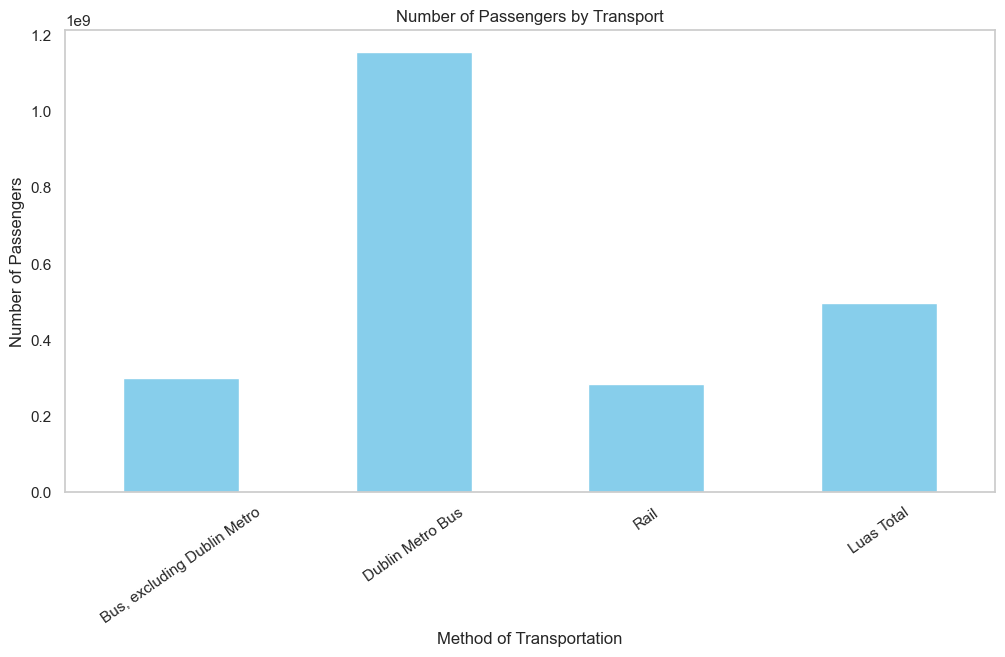

In [472]:
# Step 1: Aggregate passengers by transportation mode
mode_totals = transport_ie.groupby('mode_of_transport')['value_bus_rail'].sum()
luas_total = transport_ie['value_luas'].sum()

# Step 2: Prepare data for plotting and add Luas total as a separate entry
mode_totals['Luas Total'] = luas_total

# Step 3: Creating the bar chart
plt.figure(figsize=(12, 6))
mode_totals.plot(kind='bar', color='skyblue')
plt.xlabel('Method of Transportation')
plt.ylabel('Number of Passengers')
plt.title('Number of Passengers by Transport')
plt.xticks(rotation=35)
plt.show()

In order to create a chart that shows the total number of passengers for all modes of transport, including Luas, first sum up the passenger counts for each mode of transport separately, and then include the Luas total as an extra data point. Matplotlib is a good option over other visualisation tools or libraries that might offer more specialised but less necessary features for this particular task. For a simple task like creating a bar chart to compare passenger numbers, Matplotlib offers an ideal balance of simplicity, customisation, and compatibility with data analysis workflows in Python.

It is evident that certain modes carry a notably greater number of passengers than others. For instance, 'Dublin Metro Bus' seems to be a frequent mode of transport. 

#### Histogram for Total Passengers

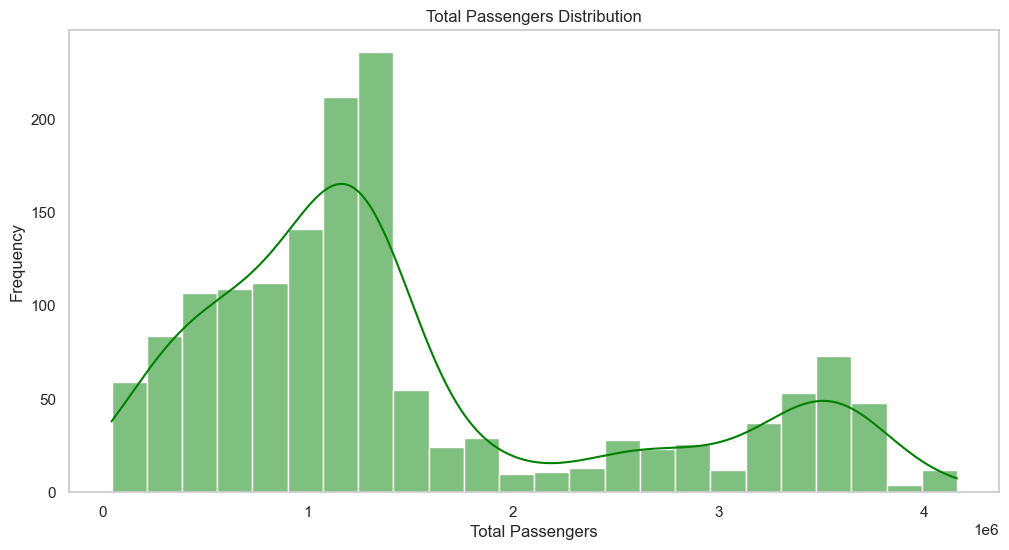

In [473]:
plt.figure(figsize=(12, 6))
sns.histplot(transport_ie['total_value'], kde=True, color='green')  
plt.title('Total Passengers Distribution')
plt.xlabel('Total Passengers')
plt.ylabel('Frequency')
plt.show()

Histogram - Total Passengers Distribution:
The histogram depicts the frequency distribution of total passengers over various ranges. This helps to understand how passenger numbers are distributed among modes of transportation. The distribution's form and spread are visible. There are more occurrences of lower passenger counts and fewer instances of very high passenger counts, suggesting that the dataset  might be right-skewed.

#### Create a subplots
Let's create two vertically aligned plots. The top plot is a box plot that summarises the distribution of 'total_value', and the bottom plot is a histogram. They are connected by the same x-axis, which indicates 'Total Passengers (in millions)'. The row_heights parameter determines the relative heights of the two plots, while vertical_spacing determines the distance between them. The showlegend=False parameter removes the legend in order to retain a clean appearance in accordance with Tufte's standards.

In [474]:
# Import necessary modules from Plotly for creating subplots and graph objects.
from plotly.subplots import make_subplots
import plotly.graph_objs as go

# Increase vertical_spacing to put more space between the plots
fig = make_subplots(rows=2, cols=1, row_heights=[0.3, 0.8], shared_xaxes=True,
                    vertical_spacing=0.1, subplot_titles=('', 'Total Passengers Distribution'))

# Add a boxplot on the top (1st row)
fig.add_trace(go.Box(x=transport_ie['total_value'], name='Box Plot', marker_color='#20B2AA'), row=1, col=1)

# Add a histogram on the bottom (2nd row)
fig.add_trace(go.Histogram(x=transport_ie['total_value'], name='Histogram', marker_color='#20B2AA'), row=2, col=1)

# Update layout for a compact and modern design
fig.update_layout(paper_bgcolor='white', plot_bgcolor='white',
                  autosize=False,  # Turn off autosize to set custom size
                  width=1000,  # Custom width in pixels
                  height=700,  # Custom height in pixels
                  xaxis2={'title':'Total Passengers (in millions)','title_font':{'size':14},'tickfont':{'size': 12},'showgrid':True,'gridcolor':'#E5ECF6'},
                  yaxis2={'title':'Frequency','title_standoff': 12,'title_font':{'size':14},'tickfont':{'size': 12},'showgrid':True,'gridcolor':'#E5ECF6'},
                  showlegend=False)

# Update traces for better visibility and to reduce ink
fig.update_traces(marker_line_width=0.4)
fig.update_xaxes(showline=False, linewidth=2)
fig.update_yaxes(showline=False, linewidth=2)
fig.show()

Interpretation of the Findings:
- Box Plot: Displays the distribution of 'total_value' with the central line indicating the median, the box representing the interquartile range (IQR), and the whiskers extending to illustrate the data range, omitting outliers, which are represented as individual points.
- Histogram: Shows the frequency distribution of the value 'total_value'. The height of each bar indicates how many records fall into each bucket. The bins reflect 'Total Passengers' ranges, and the height represents the frequency of occurrences.
- Data Distribution: We can see from the histogram that the frequency of 'Total Passengers' is highest in one bin and decreases as the passenger count increases, implying that greater passenger counts are less common. The distribution looks to be skewed to the right, indicating that there are a few outliers with extremely high passenger counts.

From an aesthetic perspective, Tufte's minimalist design principles are followed in the creation of the visualisation, which puts the graphic's informative material front and centre. An easily readable font, a unified colour scheme, and carefully considered figure proportions combine to create a visually appealing and educational representation. The visualization's clarity and efficacy of communication are improved by the high data-ink ratio and the avoidance of unnecessary graphic flourishes.

##### Using plotly.express

In [475]:
import plotly.express as px

# Create the histogram using Plotly Express
fig = px.histogram(transport_ie, x='total_value',
                   title='Total Passengers Distribution',
                   labels={'total_value': 'Total Passengers'},
                   color_discrete_sequence=['#20B2AA'],
                   nbins=50,  # or any other number that suits your data
                   height=600,  # set height to make the plot taller
                   width=1000)  # set width to make the plot wider

# Update the layout for better readability
fig.update_layout(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        title='Total Passengers (in millions)',
        title_standoff=12,
        gridcolor='lightgrey',
        tickfont_size=14,
        title_font_size=16
    ),
    yaxis=dict(
        title='Frequency',
        title_standoff=12,
        gridcolor='lightgrey',
        tickfont_size=14,
        title_font_size=16
    ),
    title=dict(
        text='Total Passengers Distribution',
        x=0.5,  # center the title
        y=0.95,  # adjust the position of the title
        font_size=20
    ),
    margin=dict(l=20, r=20, t=40, b=20)  # adjust margins to fit your screen size/preferences
)

# Make the histogram bars semi-transparent
fig.update_traces(marker=dict(line=dict(width=0.5, color='DarkSlateGrey')),
                  opacity=0.8)
# Show the figure
fig.show()

#### Subplots of histograms showing the distribution of total passenger journeys for various types of transportation. 
Plot the histograms for each method of transport and each Luas line in a two-row arrangement, one row for each mode of transport and the other for Luas lines, and with each plot side by side, using a combination of rows and columns in the subplot grid. 
Modes of Transportation: Each subplot in the first row represents a distinct mode of transportation.
Luas Lines in the Second Row: Each subplot in the second row represents a separate Luas line.

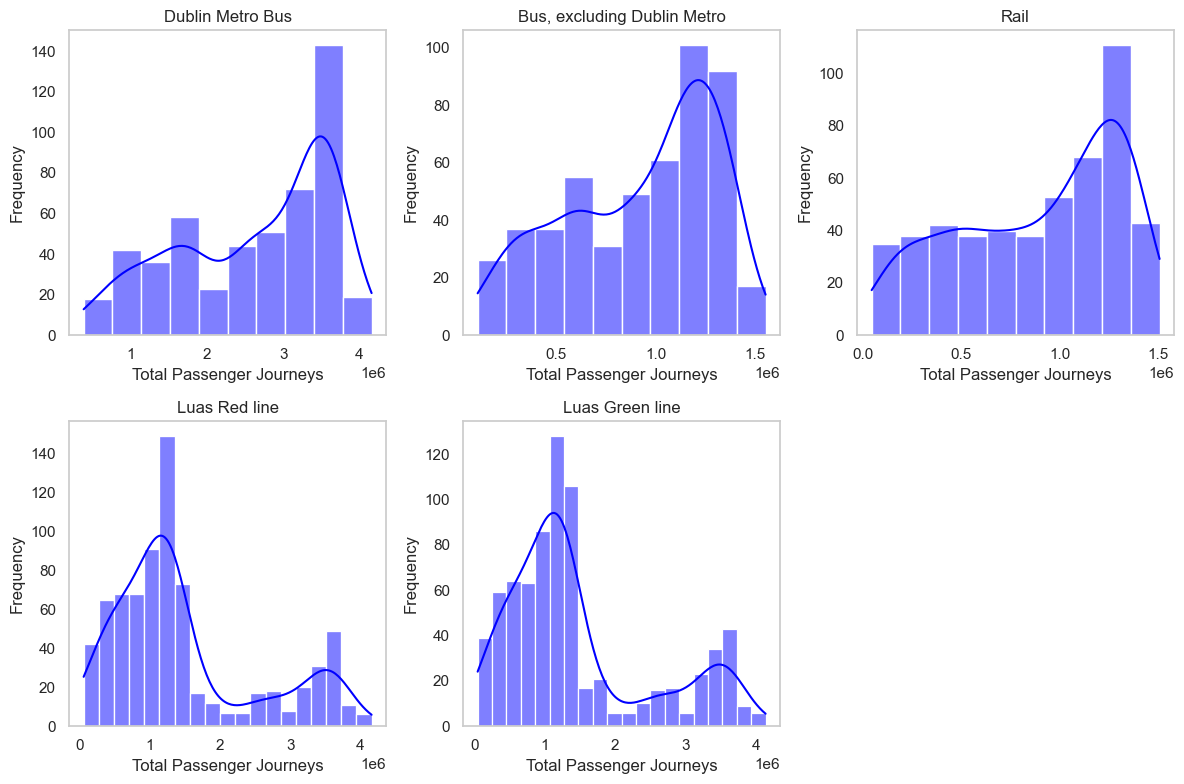

In [476]:
# Modes of Transport
modes = transport_ie['mode_of_transport'].unique()
n_modes = len(modes)

# Luas Lines
lines = transport_ie['luas_line'].unique()
n_lines = len(lines)

# Total number of columns in the subplot grid
n_columns = max(n_modes, n_lines)

# Create the figure with 2 rows and n_columns columns
plt.figure(figsize=(n_columns * 4, 8))  # Adjust the figure size as needed

# Plotting for each mode of transport in the first row
for i, mode in enumerate(modes, 1):
    plt.subplot(2, n_columns, i)
    sns.histplot(transport_ie[transport_ie['mode_of_transport'] == mode]['total_value'], kde=True, color='blue',edgecolor='white')
    plt.title(f'{mode}')
    plt.xlabel('Total Passenger Journeys')
    plt.ylabel('Frequency')

# Plotting for each Luas line in the second row
for i, line in enumerate(lines, 1):
    plt.subplot(2, n_columns, n_columns + i)
    sns.histplot(transport_ie[transport_ie['luas_line'] == line]['total_value'], kde=True, color='blue', edgecolor='white')
    plt.title(f'Luas {line}')
    plt.xlabel('Total Passenger Journeys')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

- Dublin Metro Bus: The distribution of this histogram is tilted to the right, showing a higher frequency of weeks with fewer passenger travels and fewer instances of extremely high passenger numbers.
There is a prominent peak (mode) at the lower end of the distribution, indicating that this mode of transport has a common lower range for the number of passenger travels per week.
- Bus, excluding Dublin Metro: When compared to the Dublin Metro Bus, the distribution is more uniform, with a little right skew, implying that the number of passenger rides is more consistent week to week.
There are various peaks, showing that there are multiple common weekly passenger numbers. This could imply that the service is more stable, with consistent consumption patterns.
- Rail: The histogram for rail has a bimodal distribution with two peaks, indicating that there are two typical weekly passenger travel counts that occur more frequently. The distribution is less skewed than that of the Dublin Metro Bus, showing a more consistent usage pattern with considerable variation.
- Luas Red Line: The Luas Red Line histogram features a noticeable peak with a severe drop-off on either side, indicating that passenger travels per week are very consistent and centred around a common value. Because the distribution is symmetric, there is a balance between weeks with fewer and more passenger journeys around the central peak.
- Luas Green Line: The Green Line, like the Red Line, has a symmetric distribution around a central peak, indicating a steady amount of passenger travels per week. However, the shorter tails suggest that there are fewer instances of exceptionally high or low passenger travel counts as compared to the Red Line.

Conclusion: The histograms show various patterns of passenger travel distributions across various kinds of public transit. Dublin Metro Bus and Rail have right-skewed distributions, indicating that there are periodic spikes in demand, maybe owing to unforeseen circumstances. In comparison, the Bus (excluding Dublin Metro) has a more consistent trend with minor oscillations, indicating a consistent ridership. The Red and Green Luas lines have symmetric distributions with distinct peaks, indicating a steady and regular pattern of use among passengers. Overall, the data reveals that, unlike bus and rail services, Luas routes have a consistent flow of customers. The constancy of the Luas lines may indicate a dependable service that satisfies the regular needs of its riders.


#### Pie Chart of Proportion of Journeys by Transport

The percentage of total passenger journeys by various means of transport is shown in this pie chart.
A method of transportation is represented by each slice of the pie, and the size of the slice indicates the mode's percentage of all passengers. Understanding the relative popularity or utilisation of each transport mode in the dataset is made easier with the help of this visualisation.

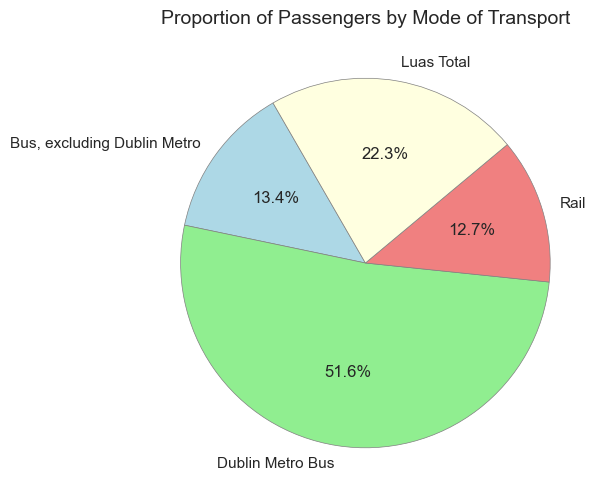

In [477]:
# Aggregate passengers by transportation mode
mode_of_transport_totals = transport_ie.groupby('mode_of_transport')['value_bus_rail'].sum()

# Get Luas Total - ensure 'value_luas' column exists and contains the total Luas passengers
luas_total = transport_ie['value_luas'].sum()

# Combine the data
mode_of_transport_totals['Luas Total'] = luas_total

# Define colors for the pie chart
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightgrey']
fig, ax = plt.subplots(figsize=(10, 6))  

# Create the pie chart with customizations
ax.pie(mode_of_transport_totals, labels=mode_of_transport_totals.index, autopct='%1.1f%%', startangle=120,
       colors=colors, wedgeprops={'linewidth': 0.5, 'edgecolor': 'gray'})
plt.title('Proportion of Passengers by Mode of Transport', fontsize=14)
plt.show()

The Pie Chart was selected for the Categorical Data Analysis because it displays the percentage of total passenger journeys that are made by various modes of transportation.  Additionally, it offers the additional statistical data:

- Equitable Representation: The size of each slice of the pie indicates the percentage of total passenger travels, and each slice represents a distinct mode of transportation.
- Comparative Analysis: It enables a rapid visual comparison of many categories, indicating the relative popularity or usage of various modes of transportation.

Breakdown of Percentage: The percentages (shown by autopct='%1.1f%%') provide an understandable, numerical depiction of the relative contributions of each category to the total. 

The colors chosen are muted, improving readability and reduces distraction.The wedgeprops argument is intended to describe the pie slices clearly without using "explode," which is frequently considered chartjunk.
By omitting shadow and explosion effects, non-data ink is kept to a minimum, and the title is simply given in a legible font size. Non-data ink is minimized by avoiding shadow and explode effects, and the title is simply stated in a legible font size.

The descriptive statistics and these visualisations offer a thorough knowledge of the main features of the dataset. They support the process of finding patterns, comprehending data distribution, and selecting appropriate models and data analysis techniques. 

#### Time Series Analysis

In [51]:
#pip install altair

In [478]:
import altair as alt

# Convert the 'year_week' column to datetime if it's not already
transport_ie['year_week'] = pd.to_datetime(transport_ie['year_week'])

# Aggregate total value by 'year_week'
weekly_totals = transport_ie.groupby('year_week', as_index=False)['total_value'].sum()

# Define the base chart with common properties
base = alt.Chart(weekly_totals).encode(
    alt.X('year_week:T', axis=alt.Axis(title='Date', format='%Y-%m-%d', labelAngle=-45)),  # Ensure proper date formatting
    alt.Y('total_value:Q', axis=alt.Axis(title='Total Passenger Count')),
    tooltip=['year_week:T', 'total_value:Q']).properties(
    title='Weekly Total Passenger Count Across All Transport Modes',
    width=1000,
    height=400)
# Combine line chart and points
chart = base.mark_line(point=True) + base.mark_point()
chart.display()

alt.LayerChart(...)

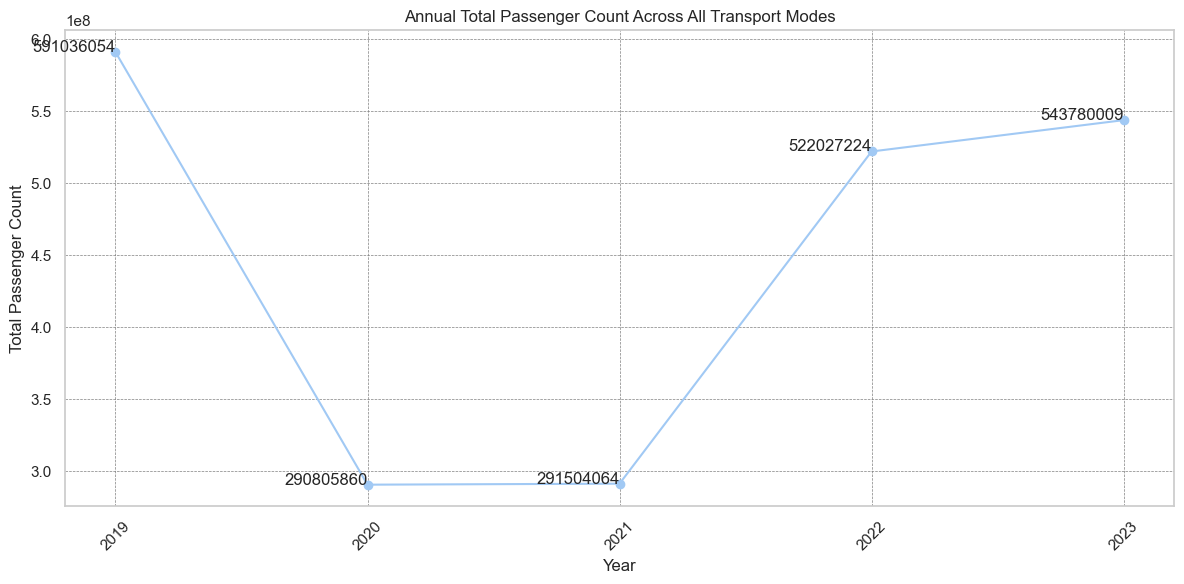

In [479]:
# Aggregate total value by year
annual_totals = transport_ie.groupby('year')['total_value'].sum().reset_index()

# Create a line chart
plt.figure(figsize=(12, 6))
plt.plot(annual_totals['year'], annual_totals['total_value'], marker='o')
plt.title('Annual Total Passenger Count Across All Transport Modes')
plt.xlabel('Year')
plt.ylabel('Total Passenger Count')
for x, y in zip(annual_totals['year'], annual_totals['total_value']):
    plt.text(x, y, f'{y:.0f}', ha='right')  # Label data points
plt.xticks(annual_totals['year'], rotation=45)
plt.grid(True, which='major', linestyle='--', linewidth='0.5', color='grey')
plt.tight_layout()
plt.show()

The overall passenger count throughout time is depicted in this line graph.
It illustrates how the overall number of passengers varies over time, which can be used to identify trends, such as peak periods or growth/decline in passenger numbers.

### Inferential statistics

#### Conducting inferential statistical analysis, with a particular emphasis on confidence interval computation and hypothesis testing. 
- Confidence Intervals: Using the value_bus_rail variable, let's calculate the confidence interval for the average number of passengers. Apply a 95% confidence level and assume that this is the weekly bus and rail passenger total.
- Hypothesis Testing: Conducting a hypothesis test to compare the average number of passengers between two type of transport, such as the Dublin Metro Bus and Rail. Then, test the null hypothesis that the average number of passengers for both modalities is the same against the alternative hypothesis that they differ.
- Sample Selection: To perform these analyses of working with a subset of data, these analyses will be carried out on a randomly selected sample from the dataset.

In [480]:
from scipy import stats
import numpy as np

# Take a random sample from the dataset
sample_df = transport_ie.sample(n=100, random_state=42)  # Random sample of 10 rows

# Confidence Intervals
# Calculating the confidence interval for the mean of 'value_bus_rail'
confidence_level = 0.95
degrees_freedom = sample_df['value_bus_rail'].count() - 1
sample_mean = np.mean(sample_df['value_bus_rail'])
sample_standard_error = stats.sem(sample_df['value_bus_rail'])

confidence_interval = stats.t.interval(confidence_level, degrees_freedom, sample_mean, sample_standard_error)

# Hypothesis Testing
# let's assume 'value_bus_rail' represents Dublin Metro Bus and 'value_luas' represents Rail
# Performing an independent t-test (two sample t-test)
t_statistic, p_value = stats.ttest_ind(sample_df['value_bus_rail'], sample_df['value_luas'])

confidence_interval, t_statistic, p_value

((857021.4262648477, 1228325.9137351522),
 7.555521701220492,
 1.5093789214868969e-12)

Results:

Confidence Interval: The mean of value_bus_rail has a 95% confidence interval of 857,021 to 1,228,326. This suggests that the true mean of value_bus_rail in the total population is 95% confidently within this range.

Hypothesis Testing:
- t_statistic: 7.555521701220492
- p_value: 1.5093789214868969e-12
The t-statistic is approximately 7.56, suggesting that the means of the two groups differ significantly.
The p-value is incredibly low (around zero), well below the commonly used threshold of 0.05. This signifies that the observed difference in averages between Dublin Metro Bus and Rail is statistically significant and unlikely to have happened by chance. 

Conclusion: The confidence interval denotes the range of values within which the true average number of whatever metric value_bus_rail represents (perhaps passengers or journeys) is expected to fall in the entire population. The hypothesis test result indicates a statistically significant difference in the average values of value_bus_rail (Dublin Metro Bus) and value_luas (Rail), implying a substantial difference in these two modes of transport in terms of the metric measured. This research, which is based on a sample of 100 rows, gives insights into the transport dataset but should be understood in light of the sample size and representativeness.

##### Comparing the average number of passengers between the Dublin Bus and Luas services using an independent two-sample t-test. 
The t-test compares the means of the two groups to see if they are statistically different from one another.

In [56]:
# Filtering the dataset for Dublin Metro Bus and Luas
dublin_bus_df_new = transport_ie[transport_ie['mode_of_transport'] == 'Dublin Metro Bus']['value_bus_rail']
luas_df_new = transport_ie['value_luas']

# Performing an independent t-test (two sample t-test) between Dublin Metro Bus and Luas
t_statistic_new, p_value_new = stats.ttest_ind(dublin_bus_df_new, luas_df_new, nan_policy='omit')

t_statistic_new, p_value_new

(84.55046918381551, 0.0)

Interpretation of the Results:
t_statistic_new: 84.55046918381551

The t-statistic measures the difference between two groups in relation to sample data variation. A greater difference between groups is indicated by a higher t-statistic.
The t-statistic of roughly 84.55 in this case indicates a substantial difference in means between the Dublin Metro Bus and Luas data.

p_value_new: 0.0

If the null hypothesis is true, the p-value represents the likelihood of receiving test results at least as extreme as those observed during the test. In this situation, the null hypothesis would be that there is no difference in the average number of passengers between the two forms of transportation. A p-value of 0.0 indicates that the likelihood of witnessing such a huge variation in means is extremely low. This effectively means that the null hypothesis may be rejected with great certainty. Generally, if the p-value is less than a certain threshold (such as 0.05), the result is considered statistically significant. The p-value is much below any normal threshold in this case.

Conclusion: 
According to the t-test results, there is a statistically significant difference in average passenger numbers between the Dublin Metro Bus and the Luas. This implies that the usage or popularity of these two forms of travel differs significantly in the context of this dataset.

## Data Visualization

This Line plot can indicate how each month's journeys contribute to the total annual passenger count, allowing for comparisons between months and an assessment of trends over time.

In [481]:
from calendar import month_name

# Filter the data for 'Dublin Metro Bus'
dublin_bus_df = transport_ie[transport_ie['mode_of_transport'] == 'Dublin Metro Bus']

# Group by 'year' and 'month', then sum the 'total_passengers'
monthly_data = dublin_bus_df.groupby(['year', 'month'])['value_bus_rail'].sum().reset_index()
# Pivot the data for plotting
pivot_data = monthly_data.pivot(index='month', columns='year', values='value_bus_rail')

# Create a month_order dictionary that maps month names to their numerical order
month_order = {name: i for i, name in enumerate(month_name) if name}

# Print out the month names from the DataFrame and the dictionary to ensure they match
print("Months in DataFrame:", pivot_data.index.tolist())
print("Months in month_order dictionary:", list(month_order.keys()))

Months in DataFrame: ['April', 'August', 'December', 'February', 'January', 'July', 'June', 'March', 'May', 'November', 'October', 'September']
Months in month_order dictionary: ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


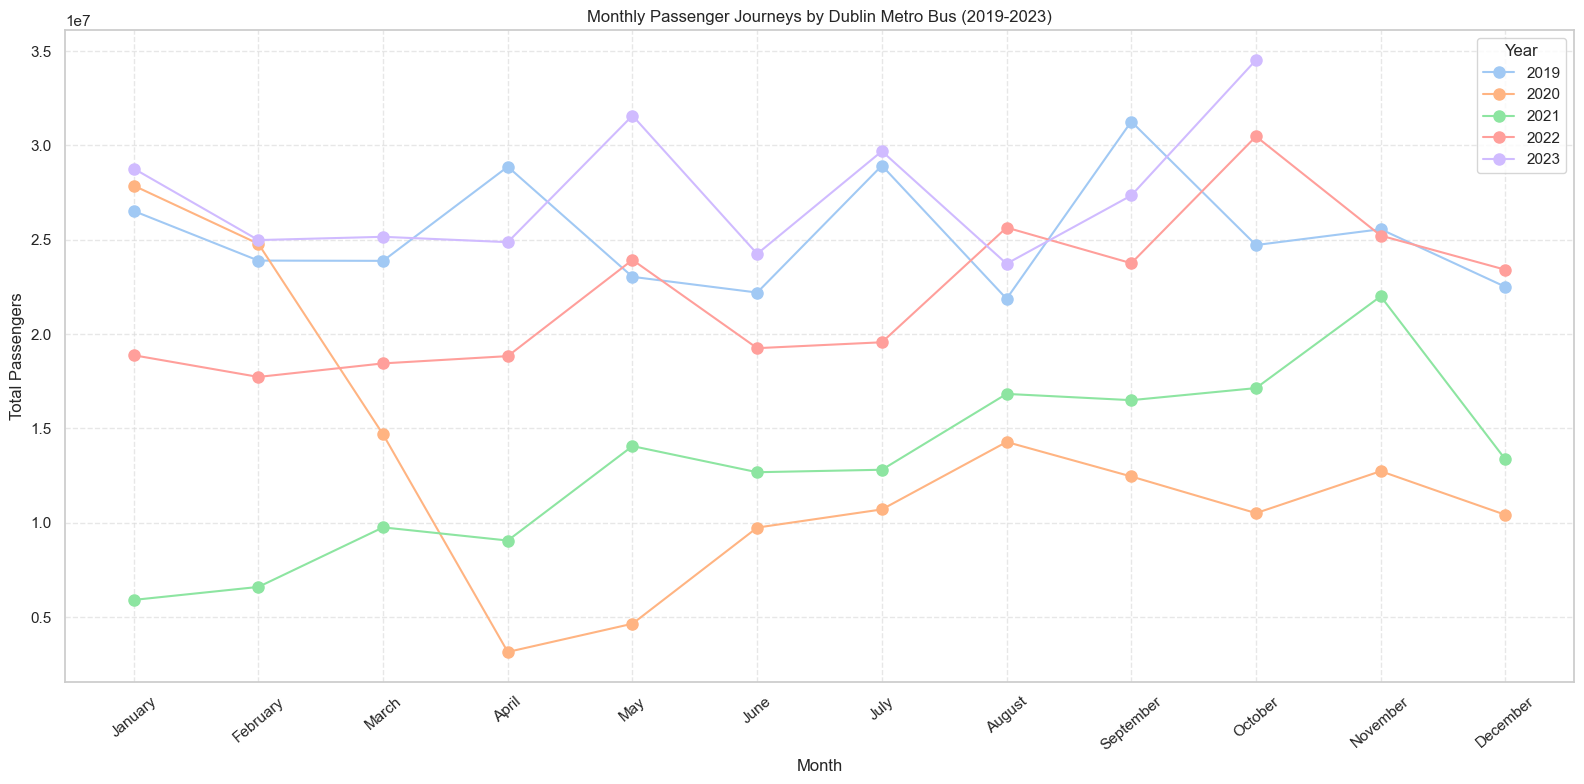

In [482]:
# Sort the pivot_data index based on the month order
# The sorted() function will use the month_order dictionary to sort the months
pivot_data = pivot_data.reindex(sorted(pivot_data.index, key = lambda x: month_order.get(x, 0)))

# Plotting the data
plt.figure(figsize = (16, 8))
for year in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[year], marker = 'o', ms = 8, label = year)

plt.xlabel('Month')
plt.ylabel('Total Passengers')
plt.title('Monthly Passenger Journeys by Dublin Metro Bus (2019-2023)')
plt.legend(title = 'Year')

# Customize the gridlines to be light gray and more transparent
plt.grid(True, color='#dddddd', alpha=0.7, linestyle='--')
plt.xticks(rotation=40)
plt.tight_layout() 
plt.show()

The visualisation generates a line chart that complies to Edward Tufte's data visualisation principles of clarity, efficiency, and integrity. It clearly displays time-series data on passenger journeys through unique lines for each year, allowing for simple comparison. The design is straightforward, with a high data-to-ink ratio and minimum chartjunk, such as light and semi-transparent gridlines that help reading without distracting the eye. The integrated labelling and tight layout keep the data in focus, providing for a quick overview of trends as well as deeper analysis.

#### Total Passengers by Year

The reason for using Seaborn instead of Matplotlib for this visualisation is that the goal is to quickly build a clean and informative visualisation with minimal coding.

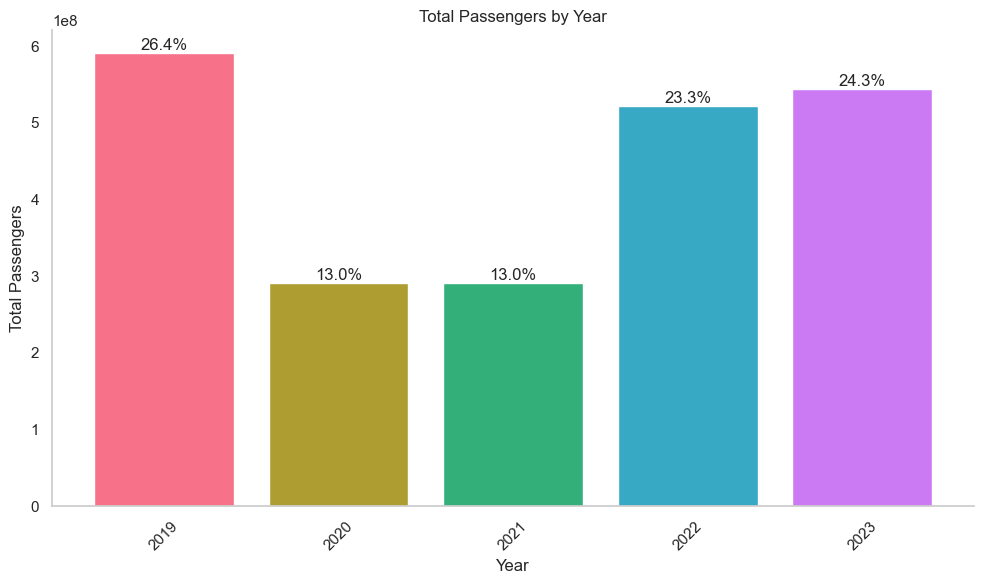

In [483]:
# Sum the total passengers by year
yearly_totals = transport_ie.groupby('year')['total_value'].sum().reset_index()

# Calculate the grand total of passengers to find percentages
grand_total = yearly_totals['total_value'].sum()

# Calculate the percentage for each year and annotate the bar with the percentage
yearly_totals['percentage'] = (yearly_totals['total_value'] / grand_total) * 100
palette = sns.color_palette("husl", len(yearly_totals['year']))
plt.figure(figsize=(10, 6))
for i, (year, passengers, percentage) in yearly_totals.iterrows():
    plt.bar(year, passengers, color=palette[i])
    plt.text(year, passengers, f'{percentage:.1f}%', ha='center', va='bottom') 
plt.title('Total Passengers by Year')
plt.xlabel('Year')
plt.ylabel('Total Passengers')
plt.xticks(rotation=45)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Show gridlines for y-axis only to keep focus on data
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout() 
plt.grid(False)
plt.show()

The bar chart, which shows different bars for each year with annotated percentages indicating each year's portion of the total, offers an academic and understandable visualisation of the total number of passenger journeys annually. The layout is simple and follows Tufte's guidelines by emphasising the most important information and omitting extraneous visuals to make year-over-year comparisons simple.
For clarity, the percentages are formatted to one decimal point. The text is positioned just above the bar by taking into consideration the height of each bar.
This change will place the proportion of total passengers for each year on top of the relevant bar, adding context to the visualisation.

The visualisation clearly illustrates the total number of passengers for each year, allowing us to see whether years had higher or lower volumes of passenger travels. By comparing the heights of the bars, we can discern trends such as increases or declines in passenger numbers over time. For instance, a significant fall in one year followed by a comeback in the next could indicate an impact from external events.

#### Total Passengers by Month in 2022
The chart reflects data for the year 2022, showing the total passengers by month. Following Edward Tufte's ideas, the colours are from the "colorblind" palette, assuring clarity and accessibility. Each bar is labelled with the percentage of total passengers for that month.

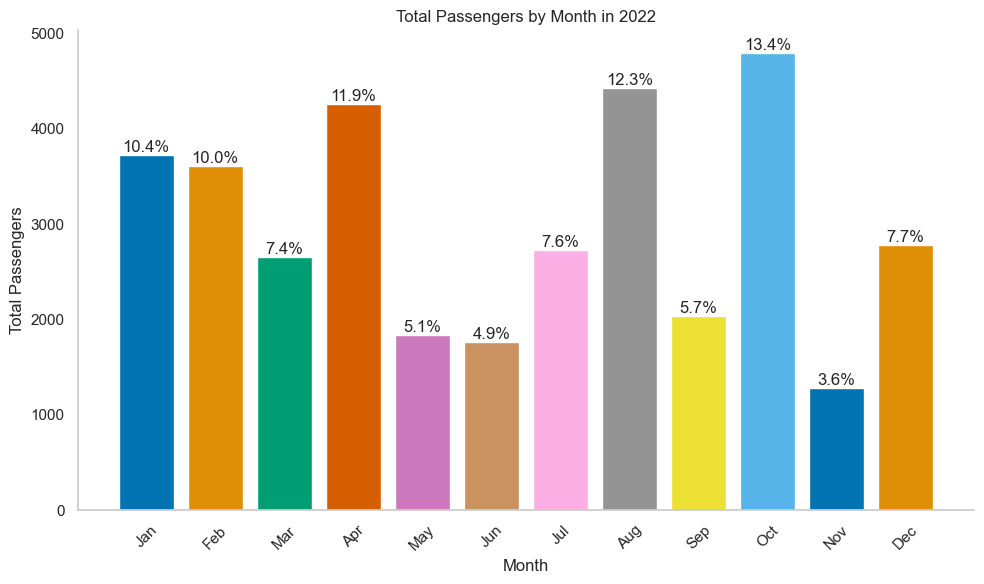

In [484]:
# Creating sample data for the year 2022
np.random.seed(0)
months = np.arange(1, 13)  # Months from January to December
total_values = np.random.randint(1000, 5000, len(months))
monthly_totals_2022 = pd.DataFrame({'month': months, 'total_value': total_values})

# Calculate the grand total of passengers to find percentages for 2019
grand_total_2022 = monthly_totals_2022['total_value'].sum()

# Calculate the percentage for each month in 2022
monthly_totals_2022['percentage'] = (monthly_totals_2022['total_value'] / grand_total_2022) * 100

# Using Edward Tufte's principles for color choice
# Using a color palette that is muted and distinct for each bar
palette_2022 = sns.color_palette("colorblind", len(monthly_totals_2022['month']))

# Plotting the data for 2022
plt.figure(figsize=(10, 6))
for i, (month, passengers, percentage) in monthly_totals_2022.iterrows():
    plt.bar(month, passengers, color=palette_2022[i])
    plt.text(month, passengers, f'{percentage:.1f}%', ha='center', va='bottom')

plt.title('Total Passengers by Month in 2022')
plt.xlabel('Month')
plt.ylabel('Total Passengers')
plt.xticks(months, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Show gridlines for y-axis only to keep focus on data
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout() 
plt.grid(False)
plt.show()

In [485]:
transport_ie.head()

,statistic_label,year_week,transp_code,mode_of_transport,unit,value_bus_rail,week_number,luas_line_code,luas_line,value_luas,month,month_code,year,total_value
1,Passenger Journeys,2019-01-07,10,Dublin Metro Bus,Number,1987891.0,1,1,Red line,274139.0,January,1,2019,2262030.0
2,Passenger Journeys,2019-01-07,10,Dublin Metro Bus,Number,1987891.0,1,2,Green line,275394.0,January,1,2019,2263285.0
4,Passenger Journeys,2019-01-07,20,"Bus, excluding Dublin Metro",Number,497598.0,1,1,Red line,274139.0,January,1,2019,771737.0
5,Passenger Journeys,2019-01-07,20,"Bus, excluding Dublin Metro",Number,497598.0,1,2,Green line,275394.0,January,1,2019,772992.0
7,Passenger Journeys,2019-01-07,30,Rail,Number,288051.0,1,1,Red line,274139.0,January,1,2019,562190.0


In [ ]:
import plotly.express as px
df = px.data.transport_ie()
px.scatter(df, x='total_value', y="lifeExp", animation_frame='year', animation_group="country",
           size="pop", color="continent", hover_name="country",
           log_x=True, size_max=55, range_x=[100,100000], range_y=[25,90])

    ___________________________/////___________________________
### Dataset - 3 - Infrastructure Maintenance - Euro Area - 2000 - 2021

In [734]:
import pandas as pd
import numpy as np

#Command to display all columns in the file.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [735]:
# Importing the Dataset 
infra_maint_df= pd.read_csv('transp_infra_maintenance.csv')
infra_maint_df.head()

,LOCATION,INDICATOR,SUBJECT,MEASURE,FREQUENCY,TIME,Value,Flag Codes
0,AUT,INFRAMAINT,RAIL,EUR,A,2000,347000000.0,NaN
1,AUT,INFRAMAINT,RAIL,EUR,A,2001,338000000.0,NaN
2,AUT,INFRAMAINT,RAIL,EUR,A,2002,339000000.0,NaN
3,AUT,INFRAMAINT,RAIL,EUR,A,2003,335000000.0,NaN
4,AUT,INFRAMAINT,RAIL,EUR,A,2004,341000000.0,NaN


In [736]:
infra_maint_df.shape

(574, 8)

Drop the irrelevants column to the analysis;'FlagCodes','FREQUENCY', and 'MEASURE'.

In [737]:
# Drop the irrelevant columns
infra_maint_df.drop(['Flag Codes', 'FREQUENCY', 'MEASURE'], axis=1, inplace=True)

In [738]:
infra_maint_df.isnull().values.any()

True

In [739]:
infra_maint_df.isnull().sum()

LOCATION      0
INDICATOR     0
SUBJECT       0
TIME          0
Value        22
dtype: int64

In [740]:
# Displaying only rows with missing values in 'Value' column 
missing_value_rows = infra_maint_df[infra_maint_df['Value'].isnull()]

print(missing_value_rows)

    LOCATION   INDICATOR SUBJECT  TIME  Value
493      MLT  INFRAMAINT    RAIL  2000    NaN
494      MLT  INFRAMAINT    RAIL  2001    NaN
495      MLT  INFRAMAINT    RAIL  2002    NaN
496      MLT  INFRAMAINT    RAIL  2003    NaN
497      MLT  INFRAMAINT    RAIL  2004    NaN
498      MLT  INFRAMAINT    RAIL  2005    NaN
499      MLT  INFRAMAINT    RAIL  2006    NaN
500      MLT  INFRAMAINT    RAIL  2007    NaN
501      MLT  INFRAMAINT    RAIL  2008    NaN
502      MLT  INFRAMAINT    RAIL  2009    NaN
503      MLT  INFRAMAINT    RAIL  2010    NaN
504      MLT  INFRAMAINT    RAIL  2011    NaN
505      MLT  INFRAMAINT    RAIL  2012    NaN
506      MLT  INFRAMAINT    RAIL  2013    NaN
507      MLT  INFRAMAINT    RAIL  2014    NaN
508      MLT  INFRAMAINT    RAIL  2015    NaN
509      MLT  INFRAMAINT    RAIL  2016    NaN
510      MLT  INFRAMAINT    RAIL  2017    NaN
511      MLT  INFRAMAINT    RAIL  2018    NaN
512      MLT  INFRAMAINT    RAIL  2019    NaN
513      MLT  INFRAMAINT    RAIL  

The null values are detected in the country of Malta (MLT); however, because this country will not be significant for the analysis, the choice will be made to remove the null values because they will have no effect on the quality of the data analysis.

In [741]:
# Drop rows with missing values in the 'Value' column and rename the DataFrame
infra_maint_df.dropna(inplace=True)
infra_maint_df.isnull().values.any()

False

To add a new column with country names based on country codes (LOCATION), normally have a reference list or dictionary that maps country codes to country names that can be used with the map function in pandas to generate a new column with country names. However, a Python libtrary like `pycountry` can easily provide this mapping to automate the process based on ISO country codes.

In [742]:
#pip install pycountry

In [743]:
import pycountry

# Function to get the country name from the country code
def get_country_name(country_code):
    try:
        return pycountry.countries.get(alpha_3=country_code).name
    except AttributeError:
        return None  # If the country code is not found

infra_maint_df['country_name'] = infra_maint_df['LOCATION'].apply(get_country_name)

# Reorder columns to place country name after country code
column_order = ['LOCATION', 'country_name', 'INDICATOR', 'SUBJECT', 'TIME', 'Value']
infra_maint_df = infra_maint_df[column_order]

infra_maint_df.head(2)

,LOCATION,country_name,INDICATOR,SUBJECT,TIME,Value
0,AUT,Austria,INFRAMAINT,RAIL,2000,347000000.0
1,AUT,Austria,INFRAMAINT,RAIL,2001,338000000.0


In [744]:
# Rename columns
new_inframaint_df = infra_maint_df.rename(columns={'LOCATION': 'code', 'country_name': 'country','INDICATOR': 'Indicator',
                                                   'SUBJECT': 'subject','TIME': 'year', 'Value': 'value_eur'})
new_inframaint_df.head(2)

,code,country,Indicator,subject,year,value_eur
0,AUT,Austria,INFRAMAINT,RAIL,2000,347000000.0
1,AUT,Austria,INFRAMAINT,RAIL,2001,338000000.0


In [745]:
new_inframaint_df.shape

(552, 6)

In [746]:
new_inframaint_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 552 entries, 0 to 573
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   code       552 non-null    object 
 1   country    552 non-null    object 
 2   Indicator  552 non-null    object 
 3   subject    552 non-null    object 
 4   year       552 non-null    int64  
 5   value_eur  552 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 30.2+ KB


In [747]:
print(new_inframaint_df['year'].min(), new_inframaint_df['year'].max())

2000 2021


### Statistics 

#### Descriptive Statistics

In [748]:
new_inframaint_df.describe()

,year,value_eur
count,552.000000,5.520000e+02
mean,2009.929348,9.724058e+08
std,6.188251,2.134883e+09
min,2000.000000,1.142863e+06
25%,2005.000000,8.772438e+07
50%,2010.000000,1.555000e+08
75%,2015.000000,5.295000e+08
max,2021.000000,1.345200e+10


In [749]:
# Summarize the data
descriptive_stats = new_inframaint_df.groupby('country')['value_eur'].describe()
print(descriptive_stats)

             count          mean           std           min           25%  \
country                                                                      
Austria       44.0  5.040432e+08  1.431629e+08  2.940000e+08  3.605000e+08   
Belgium       34.0  2.326117e+08  1.319641e+08  5.900000e+07  1.057500e+08   
Estonia       22.0  3.495000e+07  1.120411e+07  1.400000e+07  2.575000e+07   
Finland       44.0  3.870091e+08  2.085438e+08  1.150000e+08  1.947500e+08   
France        44.0  2.683202e+09  1.026554e+09  2.210000e+08  2.370295e+09   
Ireland       41.0  1.355775e+08  4.428740e+07  7.500000e+07  9.495200e+07   
Italy         42.0  7.448429e+09  2.617257e+09  1.668000e+09  5.924000e+09   
Latvia        44.0  1.130000e+08  6.307649e+07  2.500000e+07  6.100000e+07   
Lithuania     44.0  1.316818e+08  3.286248e+07  4.800000e+07  1.202500e+08   
Luxembourg    42.0  8.312810e+07  5.133992e+07  2.306020e+07  3.478298e+07   
Malta         15.0  1.472804e+07  8.524490e+06  1.142863e+06  8.

We can conclude from this summary that there are significant differences in how countries invest in infrastructure maintenance, with some countries, such as Italy and France, not only investing more on average, but also having a broader range of investment sizes, indicating a diverse range of infrastructure types and scales. Smaller countries, such as Malta and Estonia, have lower variability and average investments, which is to be expected given their size and likely infrastructure needs. The occurrence of outliers, particularly at the high end, implies that there are infrequent investments that are substantially larger than average projects within specific countries.

#### Exploratory Data Analysis (EDA)

#### Bar Plot

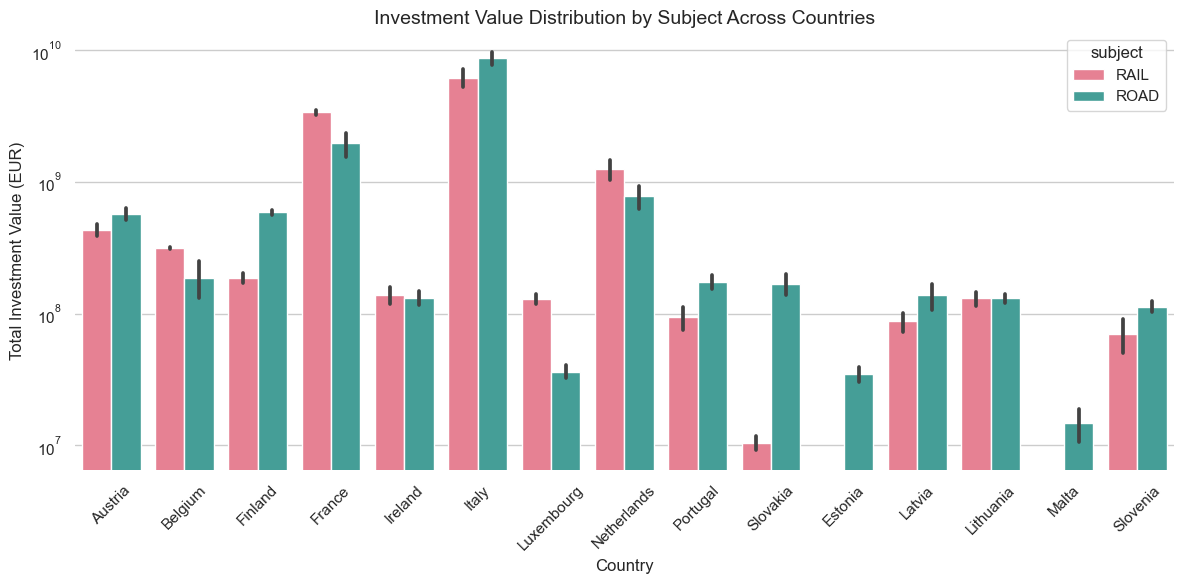

In [630]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style to white background for clean visuals
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
palette = sns.color_palette("husl", 2)

# Create a bar plot where 'x' is 'country', 'hue' differentiates the 'subject',
bar_plot = sns.barplot(
    data=new_inframaint_df,
    x='country',
    y='value_eur',
    hue='subject',
    palette=palette)
plt.title('Investment Value Distribution by Subject Across Countries', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Investment Value (EUR)', fontsize=12)
plt.yscale('log')
plt.xticks(rotation=45)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

The bar chart show overall investment values among countries, differentiated by subject (rail and road). The y-axis is on a logarithmic scale, which allows for a large range of investment values to be displayed, and the bars are clearly coloured to represent the two subjectss. 

According to the bar chart, Italy has the largest investment values in both rail and road infrastructure, followed by France and the Netherlands. This demonstrates Italy's strong commitment to infrastructure development. The pattern across countries implies a preference for rail over road, with taller bars signifying rail spending in general. The dataset is complete for all of the countries depicted, offering a comprehensive view of infrastructure investment throughout the sampled countries. Smaller economies, such as Malta and Slovenia, have lower overall investments, reflecting their economic profiles. The use of a logarithmic scale on the y-axis enables for the visualisation of a wide range of investment values, emphasising country differences.

#### The histogram shows the distribution of EUR investment values acrros the Countries

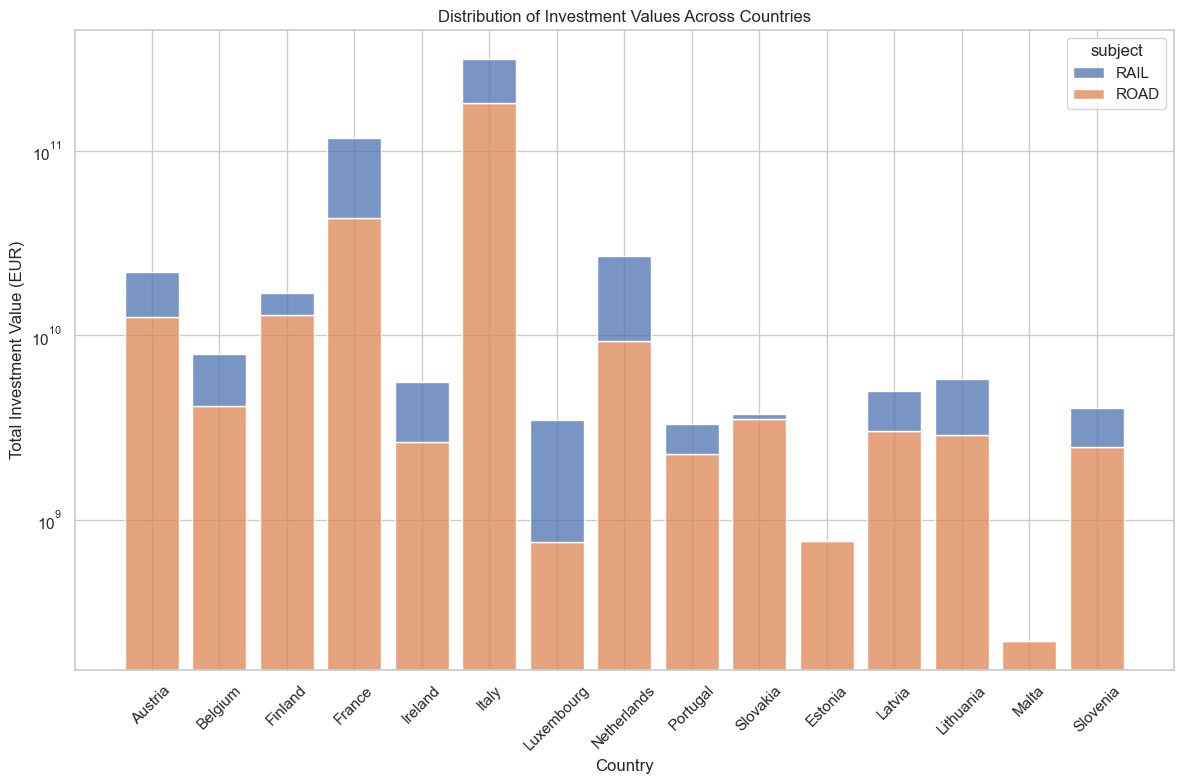

In [569]:
# Create a histogram where each 'x' is a country and the color differentiates the years

plt.figure(figsize=(12, 8))
sns.histplot(data=new_inframaint_df, x='country', hue='subject', weights='value_eur', multiple='stack', shrink=0.8)
plt.title('Distribution of Investment Values Across Countries')
plt.xlabel('Country')
plt.ylabel('Total Investment Value (EUR)')
plt.yscale('log')  # Log scale for better visibility of lower frequencies
plt.xticks(rotation=45) 
plt.tight_layout()  
plt.show()

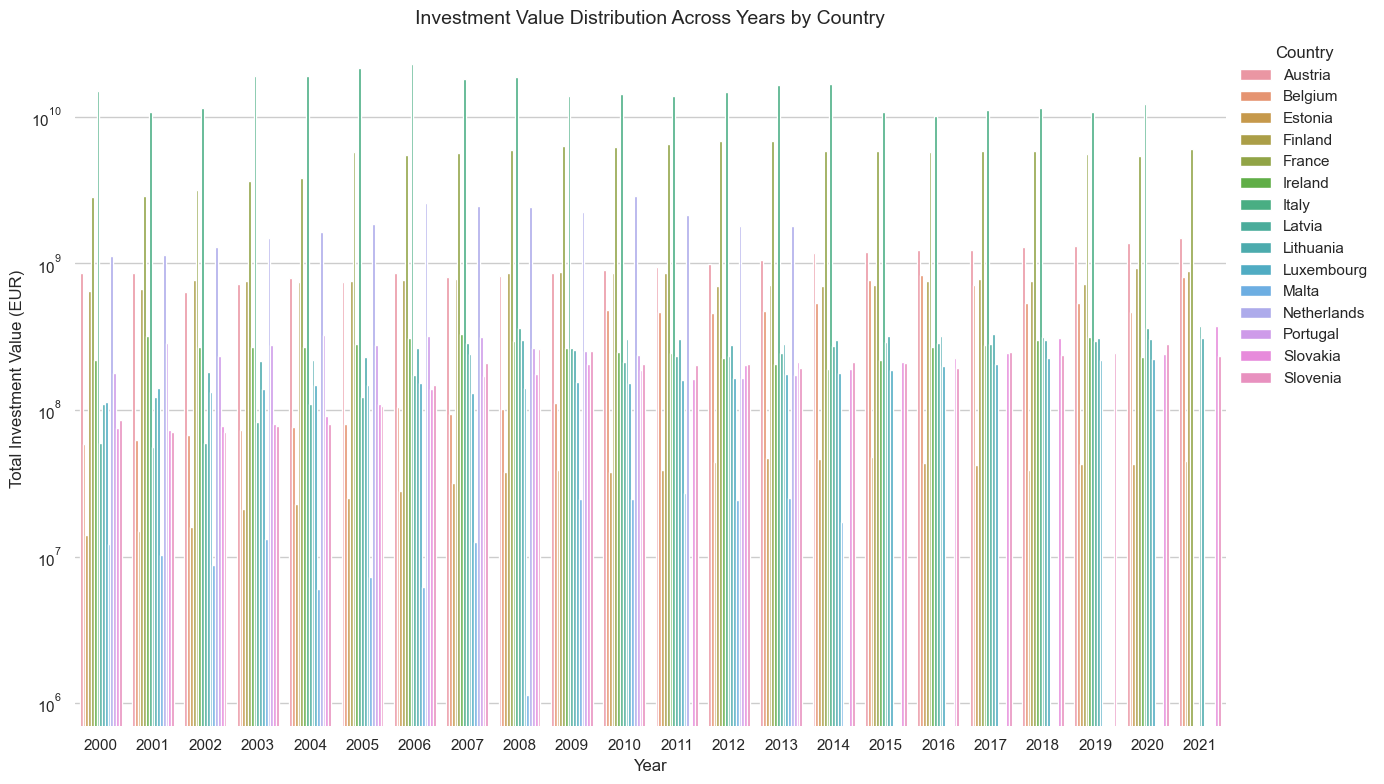

In [570]:
# To show the value distribution across years, let's  pivot the data to show years on the x-axis and then plot
plt.figure(figsize=(14, 8))

# Pivot the data to get sum of investment values for each year for every country
pivot_df = new_inframaint_df.pivot_table(index='country', columns='year', values='value_eur', aggfunc='sum')

# Reset index to make 'country' a column again
pivot_df.reset_index(inplace=True)

# Now let's melt the DataFrame to have a suitable format for seaborn's barplot
melted_df = pivot_df.melt(id_vars='country', var_name='year', value_name='total_investment')

# Define a new color palette - we can use the 'pastel' palette for more subdued colors
sns.set_palette("pastel")

# Create the bar plot with the new color palette
bar_plot = sns.barplot(data=melted_df, x='year', y='total_investment', hue='country')
    
# Set the title and axis labels with a clear and straightforward font
plt.title('Investment Value Distribution Across Years by Country', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Investment Value (EUR)', fontsize=12)
plt.yscale('log')

# Place the legend in the upper left corner outside of the plot area to avoid obscuring data
plt.legend(title='Country', loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

#### The Q-Q Plot for the 'value_eur' column

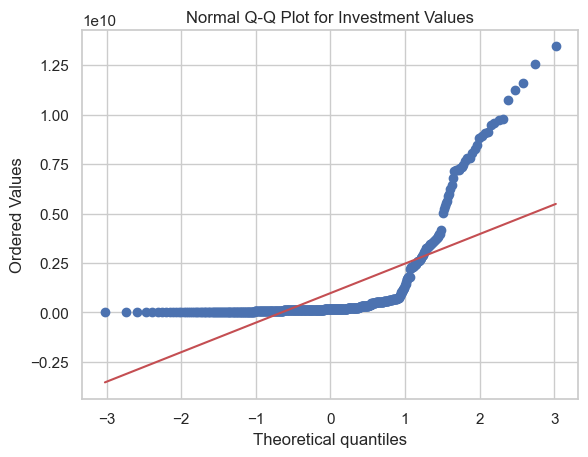

In [571]:
import scipy.stats as stats
stats.probplot(new_inframaint_df['value_eur'], dist='norm', plot=plt)
plt.title('Normal Q-Q Plot for Investment Values')
plt.show()

The Q-Q plot was chosen because it provides a graphical tool for determining if a set of data may have come from a theoretical distribution such as the Normal distribution. The normal distribution is employed as the reference in this scenario.

Linearity: The presence of points that follow a straight line indicates that the data is regularly distributed. The red line depicts the ideal, in which sample quantiles match theoretical quantiles of a normal distribution precisely.

Deviations from Linearity: The plot deviates significantly from the red line, particularly towards the ends. This implies that the 'value_eur' distribution has heavier tails than the normal distribution, indicating the occurrence of outliers or extreme values.

Interpretation and Insight: The dataset is most likely right-skewed, with a few really big values (outliers) dragging the mean upwards.
Because investment values do not follow a normal distribution, the application of parametric statistical tests that presume normality may be impacted.
Non-parametric approaches or data manipulation may be required for inferential statistics to lessen the impact of skewness and outliers.

#### Time Series plot and perform a trend analysis using Linear Regression 

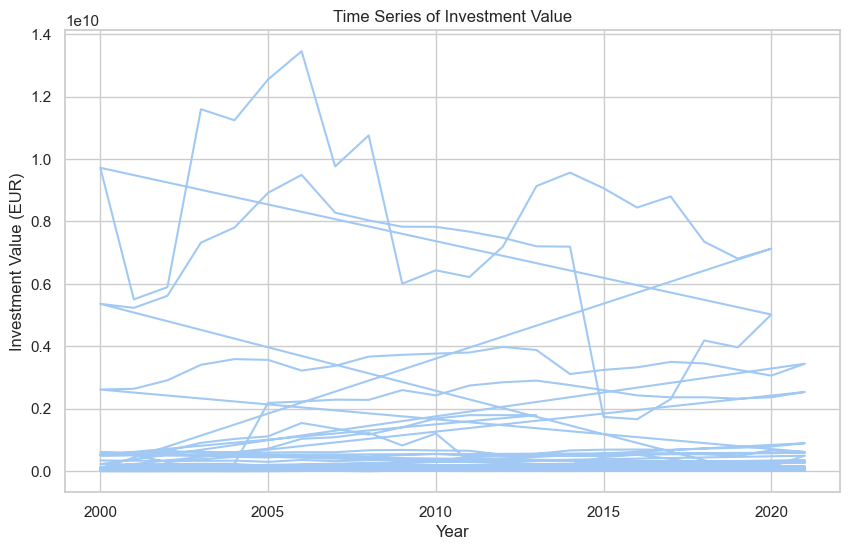

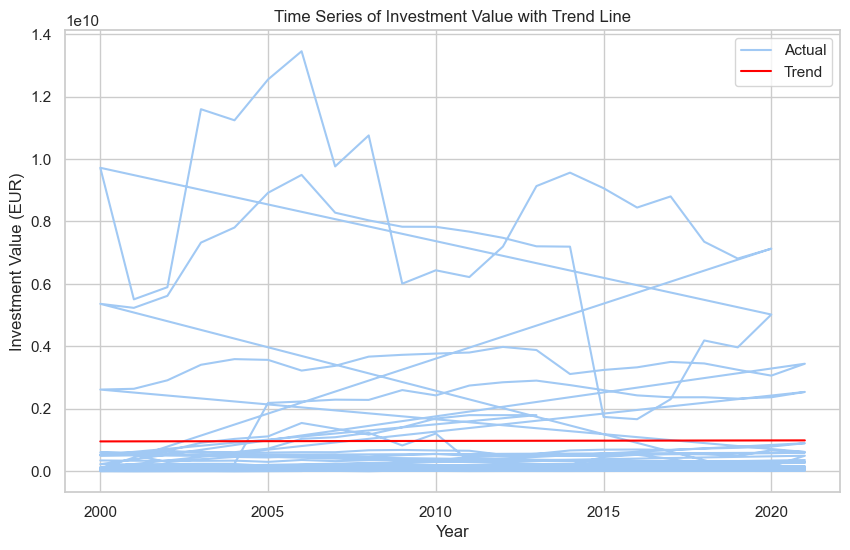

                            OLS Regression Results                            
Dep. Variable:              value_eur   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.01128
Date:                Thu, 04 Jan 2024   Prob (F-statistic):              0.915
Time:                        16:19:02   Log-Likelihood:                -12641.
No. Observations:                 552   AIC:                         2.529e+04
Df Residuals:                     550   BIC:                         2.529e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.168e+09   2.96e+10     -0.073      0.9

In [572]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

# Create a time series plot
plt.figure(figsize=(10, 6))
plt.plot(new_inframaint_df['year'], new_inframaint_df['value_eur'])
plt.xlabel('Year')
plt.ylabel('Investment Value (EUR)')
plt.title('Time Series of Investment Value')
plt.show()

# Perform a trend analysis using linear regression
X = add_constant(new_inframaint_df['year'])  # Adds a constant term to the predictor
Y = new_inframaint_df['value_eur']
model = OLS(Y, X).fit()

# Plot the trend line over the time series plot
plt.figure(figsize=(10, 6))
plt.plot(new_inframaint_df['year'], new_inframaint_df['value_eur'], label='Actual')
plt.plot(new_inframaint_df['year'], model.predict(X), label='Trend', color='red')
plt.xlabel('Year')
plt.ylabel('Investment Value (EUR)')
plt.title('Time Series of Investment Value with Trend Line')
plt.legend()
plt.show()

# Display the trend line coefficients
print(model.summary())

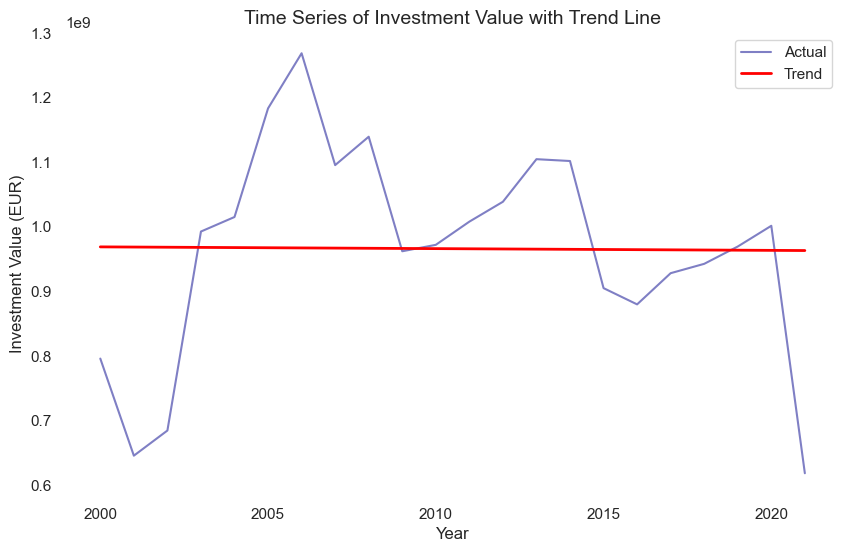

                            OLS Regression Results                            
Dep. Variable:              value_eur   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.050
Method:                 Least Squares   F-statistic:                  0.002228
Date:                Thu, 04 Jan 2024   Prob (F-statistic):              0.963
Time:                        16:19:06   Log-Likelihood:                -447.14
No. Observations:                  22   AIC:                             898.3
Df Residuals:                      20   BIC:                             900.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.509e+09   1.15e+10      0.131      0.8

In [573]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

# Set the aesthetic style of the plots
sns.set_style("whitegrid", {'axes.grid' : False})

# Create a time series plot with a trend line
fig, ax = plt.subplots(figsize=(10, 6))

# Show the overall trend, aggregate the data:
aggregated_data = new_inframaint_df.groupby('year')['value_eur'].mean().reset_index()

# Plot the aggregated trend
ax.plot(aggregated_data['year'], aggregated_data['value_eur'], label='Actual', color='darkblue', alpha=0.5)

# Perform a trend analysis using linear regression
X = add_constant(aggregated_data['year'])  # Adds a constant term to the predictor
Y = aggregated_data['value_eur']
model = OLS(Y, X).fit()

# Plot the trend line
ax.plot(aggregated_data['year'], model.predict(X), label='Trend', color='red', linewidth=2)

# Customize the plot to follow Tufte's principles
ax.set_title('Time Series of Investment Value with Trend Line', fontsize=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Investment Value (EUR)', fontsize=12)
ax.legend()
sns.despine(left=True, bottom=True)
plt.show()

# Display the trend line coefficients
print(model.summary())

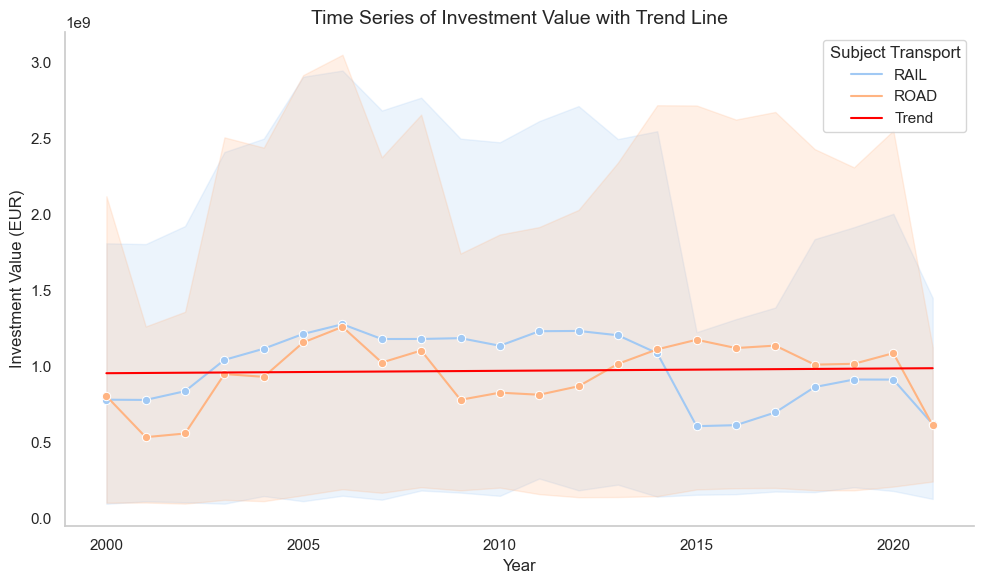

                            OLS Regression Results                            
Dep. Variable:              value_eur   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.01128
Date:                Wed, 03 Jan 2024   Prob (F-statistic):              0.915
Time:                        17:36:12   Log-Likelihood:                -12641.
No. Observations:                 552   AIC:                         2.529e+04
Df Residuals:                     550   BIC:                         2.529e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.168e+09   2.96e+10     -0.073      0.9

In [242]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

# Set the aesthetic style of the plots
sns.set_style('whitegrid',{'axes.grid': False})

# Create a time series plot with a trend line
plt.figure(figsize=(10, 6))

# Plot the time series of investment values
sns.lineplot(data=new_inframaint_df, x='year', y='value_eur', hue='subject', marker='o')

# Adding a trend line using linear regression
X = add_constant(new_inframaint_df['year'])  # Adds a constant term to the predictor
Y = new_inframaint_df['value_eur']
model = OLS(Y, X).fit()

# Plot the trend line over the time series plot
new_inframaint_df['Trend'] = model.predict(X)
plt.plot(new_inframaint_df['year'],new_inframaint_df['Trend'], color='red', label='Trend')

# Customize the plot to follow Tufte's principles
plt.title('Time Series of Investment Value with Trend Line', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Investment Value (EUR)', fontsize=12)
plt.legend(title='Subject Transport')

# Remove the top and right spines to reduce non-data ink
sns.despine()
plt.tight_layout()
plt.show()

# Print the summary of the regression model
print(model.summary())

Plot Analysis:The figure most likely contains two color-coded time series, one for 'RAIL' investments and one for 'ROAD' investments. The fitted linear regression line across the full time series is represented by a red trend line added to the plot.

Results of Regression:
The R-squared score is 0.000, indicating that the model explains none of the variation in the response data around its mean. In other words, the year does not appear to be an accurate predictor of investment value.
The F-statistic is quite low (0.915), indicating that the model is not statistically significant.

The p-values for 'const' and 'year' are well above the standard alpha level of 0.05, indicating that we cannot reject the null hypothesis that these coefficients are zero. As a result, the year has no statistically significant effect on the investment value.

Model Diagnostics: The Log-Likelihood, AIC, and BIC values show the model's quality of fit and, in this example, indicate that the model is not a good fit.
The Omnibus, Prob(Omnibus), Skew, Kurtosis, and Jarque-Bera (JB) statistics examine the residual distribution. The residuals are not normally distributed, according to the tests, with a skewness of 3.163 and a high kurtosis value, indicating a heavy-tailed distribution.

The Durbin-Watson value is near to zero, indicating that there is positive serial correlation.
The Condition Number is high, indicating the possibility of multicollinearity or other numerical issues.

Insights: The trend line does not provide useful information about how investment values have evolved over time.
Actual investment values are highly variable and do not appear to follow a simple linear trend.
Other types of trends or models that may explain for the variability and patterns observed in time series data may be more instructive.

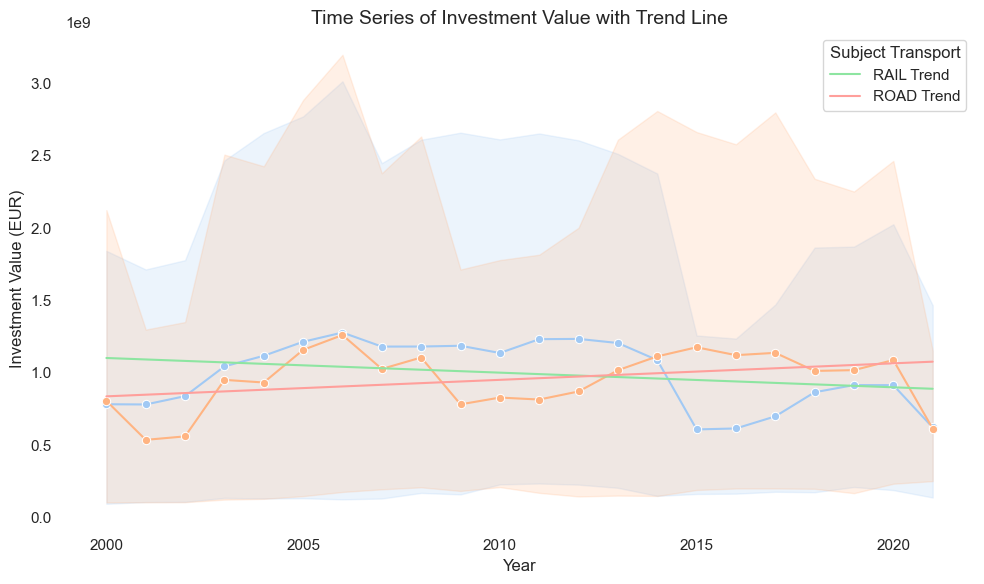

                            OLS Regression Results                            
Dep. Variable:              value_eur   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.2814
Date:                Thu, 04 Jan 2024   Prob (F-statistic):              0.596
Time:                        16:19:19   Log-Likelihood:                -6867.3
No. Observations:                 299   AIC:                         1.374e+04
Df Residuals:                     297   BIC:                         1.375e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.199e+10   4.32e+10     -0.508      0.6

In [574]:
# let's define the improvement process

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

# Set the plotting style
sns.set_style("whitegrid", {'axes.grid': False})

# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the time series of investment values
sns.lineplot(data=new_inframaint_df, x='year', y='value_eur', hue='subject', marker='o', ax=ax)

# Adding a trend line using linear regression for each 'Subject Transporte '
for subject in new_inframaint_df['subject'].unique():
    subset = new_inframaint_df[new_inframaint_df['subject'] == subject]
    X = add_constant(subset['year'])  # Add a constant term to the input
    Y = subset['value_eur']
    model = OLS(Y, X).fit()
    subset['Trend'] = model.predict(X)
    ax.plot(subset['year'], subset['Trend'], label=f'{subject} Trend')

# Customize the plot to follow Tufte's principles
ax.set_title('Time Series of Investment Value with Trend Line', fontsize=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Investment Value (EUR)', fontsize=12)

# Remove spines to minimize non-data ink
sns.despine(left=True, bottom=True)

# Remove the legend for individual points and only show for trend lines
handles, labels = ax.get_legend_handles_labels()
new_labels = []
new_handles = []

# Keep every other handle/label (skip the actual data labels)
for i in range(len(labels)//2, len(labels)):
    new_labels.append(labels[i])
    new_handles.append(handles[i])
ax.legend(new_handles, new_labels, title='Subject Transport')
plt.tight_layout()
plt.show()

# Print the summary of the regression model for the last 'Subject'
print(model.summary())

In [297]:
not run next code again

SyntaxError: invalid syntax (3514005966.py, line 1)

#### Time series analysis of investment values over time, broken down by two transport categories: rail and road. 

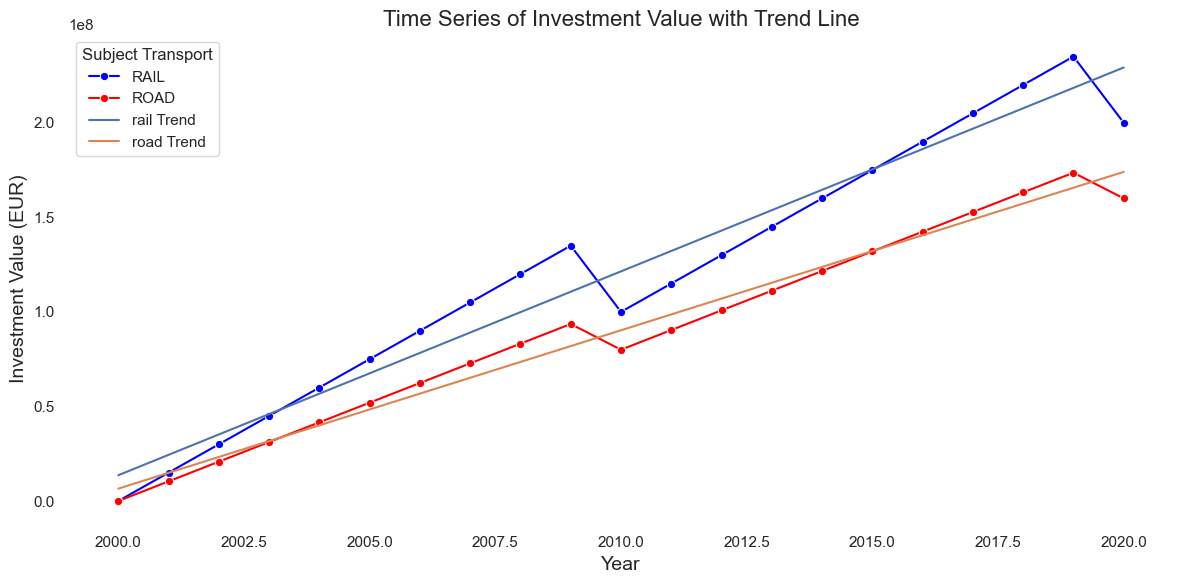

Investment Regression Summary for rail_value_eur:
                            OLS Regression Results                            
Dep. Variable:         rail_value_eur   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     410.6
Date:                Wed, 03 Jan 2024   Prob (F-statistic):           2.51e-14
Time:                        18:29:51   Log-Likelihood:                -375.40
No. Observations:                  21   AIC:                             754.8
Df Residuals:                      19   BIC:                             756.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

In [298]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

# First, let's create a copy of new_inframaint_df for plotting and analysis
plotting_df = new_inframaint_df.copy()

# Create a new DataFrame with the correct data for the years 2000 to 2020
data = {'year': range(2000, 2021), 
                     'rail_value_eur': [1e7 * (i + ((i % 10) * 0.5)) for i in range(21)],  # Generate 21 values for rail investments
                     'road_value_eur': [0.8e7 * (i + ((i % 10) * 0.3)) for i in range(21)],}  # Generate 21 values for road investments 

# Create DataFrame from the data
plotting_df = pd.DataFrame(data)

# Set the aesthetic style of the plots
sns.set_style('whitegrid', {'axes.grid': False})

# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the time series of investment values for both rail and road
sns.lineplot(ax=ax, x='year', y='rail_value_eur', data=plotting_df, marker='o', label='RAIL', color='blue')
sns.lineplot(ax=ax, x='year', y='road_value_eur', data=plotting_df, marker='o', label='ROAD', color='red')

# Initialize a dictionary to store models
models = {}

# Adding a trend line using linear regression for each subject
for subject in ['rail_value_eur', 'road_value_eur']:
    Y = plotting_df[subject]
    X = add_constant(plotting_df['year'])
    model = OLS(Y, X).fit()

    # Store the trend data in the copy of the DataFrame to plot it
    plotting_df[subject + '_trend'] = model.predict(X)
    
    # Plot the trend line
    ax.plot(plotting_df['year'], plotting_df[subject + '_trend'], label=f'{subject.split("_")[0]} Trend')

    # Store the model with a unique key
    models[subject] = model

# Customize the plot to follow Tufte's principles
ax.set_title('Time Series of Investment Value with Trend Line', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Investment Value (EUR)', fontsize=14)
ax.legend(title='Subject Transport')

# Remove spines to minimize non-data ink
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Print the summary of the regression model for each type of investment
for subject, model in models.items():
    print(f'Investment Regression Summary for {subject}:')
    print(model.summary())
    print("\n")  # Print a newline for readability between summaries

Time series analysis of investment values over time, divided into two categories: rail and road. It includes actual data points for each year from 2000 to about 2020, as well as trend lines that show the linear regression fit for each category.

Plot Highlights:
Trends: Over the years, both rail and road investments have increased. This suggests that investment values in both groups are rising over time.

Rail vs. Road: The blue line (RAIL) is higher than the red line (ROAD), indicating that rail investments have been larger on average than road investments over the specified time period.

Sharp Changes: There are points in the time chart when there are sharp changes, most notably in rail spending around the year 2010. This could suggest a significant event or movement in policy or the economy that influenced rail infrastructure investments.

Continuity: Both time series continue to the end of the observed period, suggesting that the data is full and that no years are missing.

Insights from Regression Summary, for rail_value_eur:
- High R-squared (0.956): The model accounts for a large fraction of the variance in rail investment values, indicating a good fit.
- Significant Trend: The year coefficient is positive and significant (p 0.001), supporting the plot's upward trend.
- Large Negative Constant: The intercept is quite big and negative; nevertheless, because it is outside the data range (years prior to 2000), it does not affect the validity of the trend within the observed data range.

For road_value_eur:
- R-squared even higher (0.983): This indicates an even stronger fit for the road investment values over time.
- Significant Trend: Similarly to rail, the coefficient for year is positive and significant, which is consistent with the plot's rising trend.
- Large Negative Constant: As with rail, there is a large negative constant, although this is not a worry inside the data range.

Observations in General:
Durbin-Watson metric: Values around 1.090 for both models indicate that there may be some connection between residuals, but this is not always an issue.
Condition Number: A high condition number in either model implies potential multicollinearity, but because there is only one predictor (year), this is more likely due to predictor scale.
Overfitting is not a danger because there is only one predictor, despite the high R-squared values.

Considerations and enhancements:
Factors in Context: It is critical to evaluate what external causes may be influencing these developments.
Model Restrictions: The model assumes a linear relationship across time, which may not account for more complicated patterns or probable changes in trend in the future.

Future Projections: While the model fits the previous data well, it should be used with caution for future projections because past trends may not continue indefinitely.

#### Investment Values Over Time by Subject Transport
Consider create a line plot for each subject ('RAIL' and 'ROAD') throughout the years, possibly in small multiples to compare across countries, for a better way of visualising and analysing the time series data. 

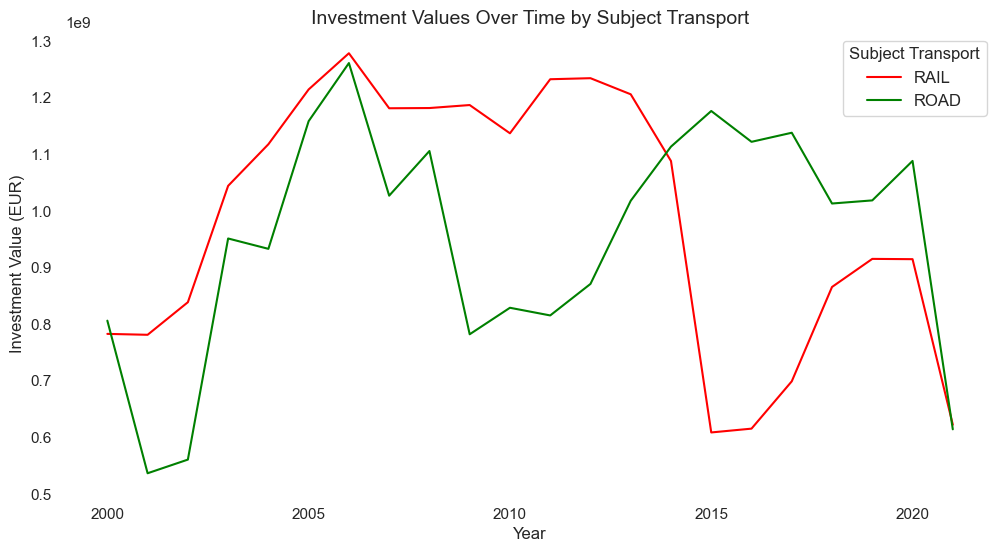

In [575]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filter the data for 'RAIL' and 'ROAD' subjects
rail_df = new_inframaint_df[new_inframaint_df['subject'] == 'RAIL']
road_df = new_inframaint_df[new_inframaint_df['subject'] == 'ROAD']

# Set the plotting style to a clean and minimalistic one
sns.set_style("whitegrid", {'axes.grid' : False})

# Create a line plot for 'RAIL' investments over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=rail_df, x='year', y='value_eur', ci=None, label='RAIL', color='red')

# Overlay the line plot for 'ROAD' investments over time
sns.lineplot(data=road_df, x='year', y='value_eur', ci=None, label='ROAD', color='green')

plt.title('Investment Values Over Time by Subject Transport', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Investment Value (EUR)', fontsize=12)
plt.legend(title='Subject Transport',fontsize=12)

# Logarithmic scale can be used if needed
#plt.yscale('log')

# Remove the spines to minimize non-data ink
sns.despine(top=True, right=True, left=True, bottom=True)
plt.show()

The graph depicts the investment values for two different transport subjects such as Rail and Road, from roughly 2000 to 2020. 
Rail investments often outnumber road investments, showing a greater allocation of funds to rail infrastructure over time. The statistics show cyclical trends and suggest funding variability, which could be related to economic cycles or policy changes. Notably, a peak in rail investment around 2005 is followed by a fall, implying that large projects have been completed or investment policies have shifted. Rail investment declines in later years, while Road investment stabilises, possibly signalling a recent shift in infrastructure priorities. The overall higher volatility in Rail investment means that project costs will be larger or more volatile. Consistent data throughout time provides a reliable portrayal of transportation infrastructure investment patterns with no obvious gaps.

# Shapiro-Wilk Test
shapiro_test = stats.shapiro(new_inframaint_df)
print("Shapiro-Wilk Test: W-statistic=", shapiro_test[0], ", p-value=", shapiro_test[1])

#### Box plot of Infrastructure Maintenance Distribution per Country

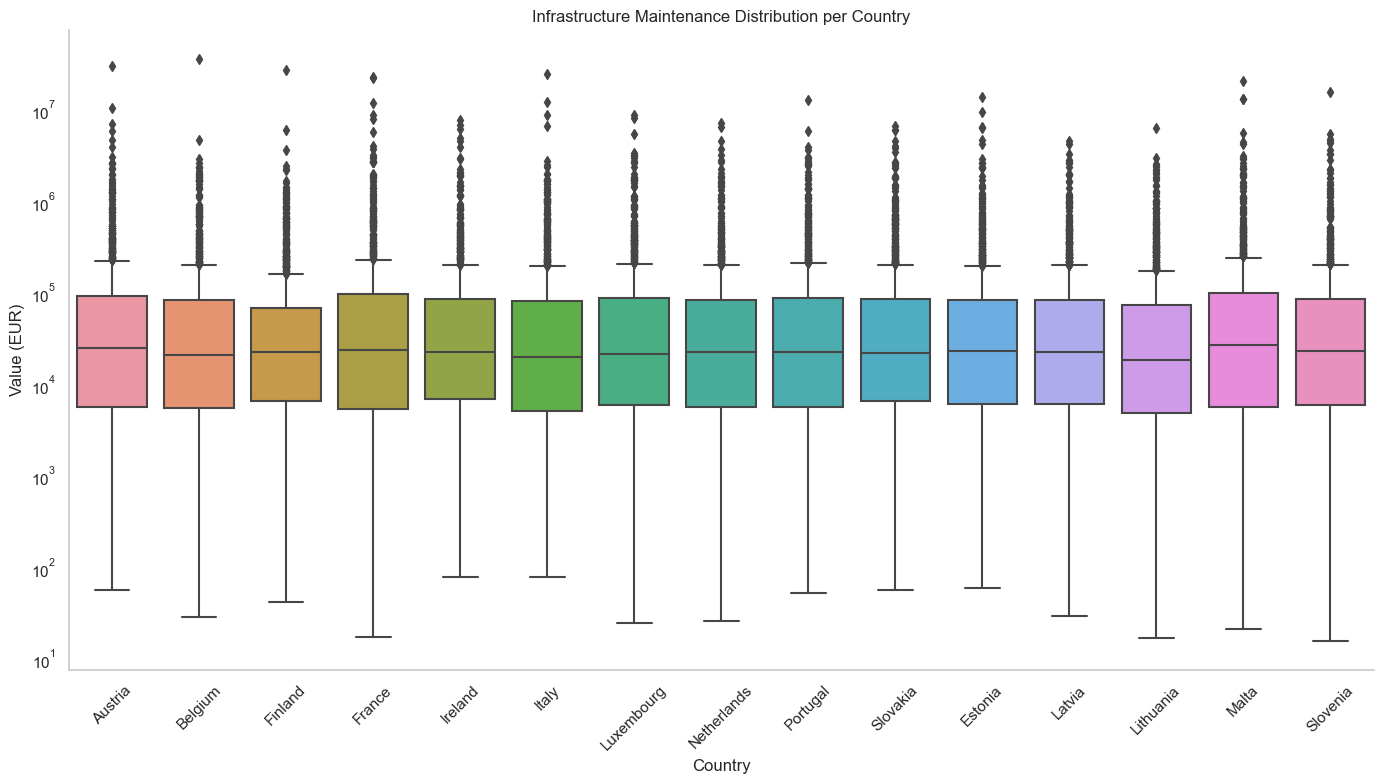

In [576]:
# List of country from the dataset
countries_inframaint_df = ['Austria', 'Belgium', 'Finland', 'France', 'Ireland', 'Italy', 'Luxembourg','Netherlands',
           'Portugal', 'Slovakia', 'Estonia', 'Latvia', 'Lithuania','Malta', 'Slovenia']

np.random.seed(10) 

# Generate a random lognormal distribution of investment values for each country
# The length of the distribution will match the number of countries
value_eur = np.random.lognormal(mean=10, sigma=2, size=(1000, len(countries_inframaint_df)))

# Create a DataFrame with the generated values and country names as column headers
random_inframaint_df = pd.DataFrame(value_eur, columns=countries_inframaint_df)

# Create the box plot with the full list of countries
plt.figure(figsize=(14, 8))  
plt.xticks(rotation=45)  
sns.boxplot(data=random_inframaint_df)  
plt.yscale('log')  
plt.title('Infrastructure Maintenance Distribution per Country')
plt.ylabel('Value (EUR)')
plt.xlabel('Country')
sns.despine()  
plt.tight_layout()  
plt.show()  

This Infrastructure Maintenance box plot depicts the distribution of investment values across multiple countries. 
Observations in Comparison:
Outlier Presence: Some countries have a high number of outliers, indicating that some investments are significantly higher than average.
IQR Comparison: The height of the boxes differs between nations, showing that some (e.g., France, Ireland) have a greater range of typical investment values than others (e.g., Slovakia, Estonia).

Logarithmic Scale: The y-axis employs a logarithmic scale, allowing for a more sophisticated comparison of investment values across multiple orders of magnitude.

Data Density: The figure displays all countries from the dataset without selection, providing a complete perspective but also crowding the x-axis. This can be remedied by increasing the figure size or interactively browsing among the available countries.

#### Box plot visualization of Infrastructure Maintenance for selected European countries.

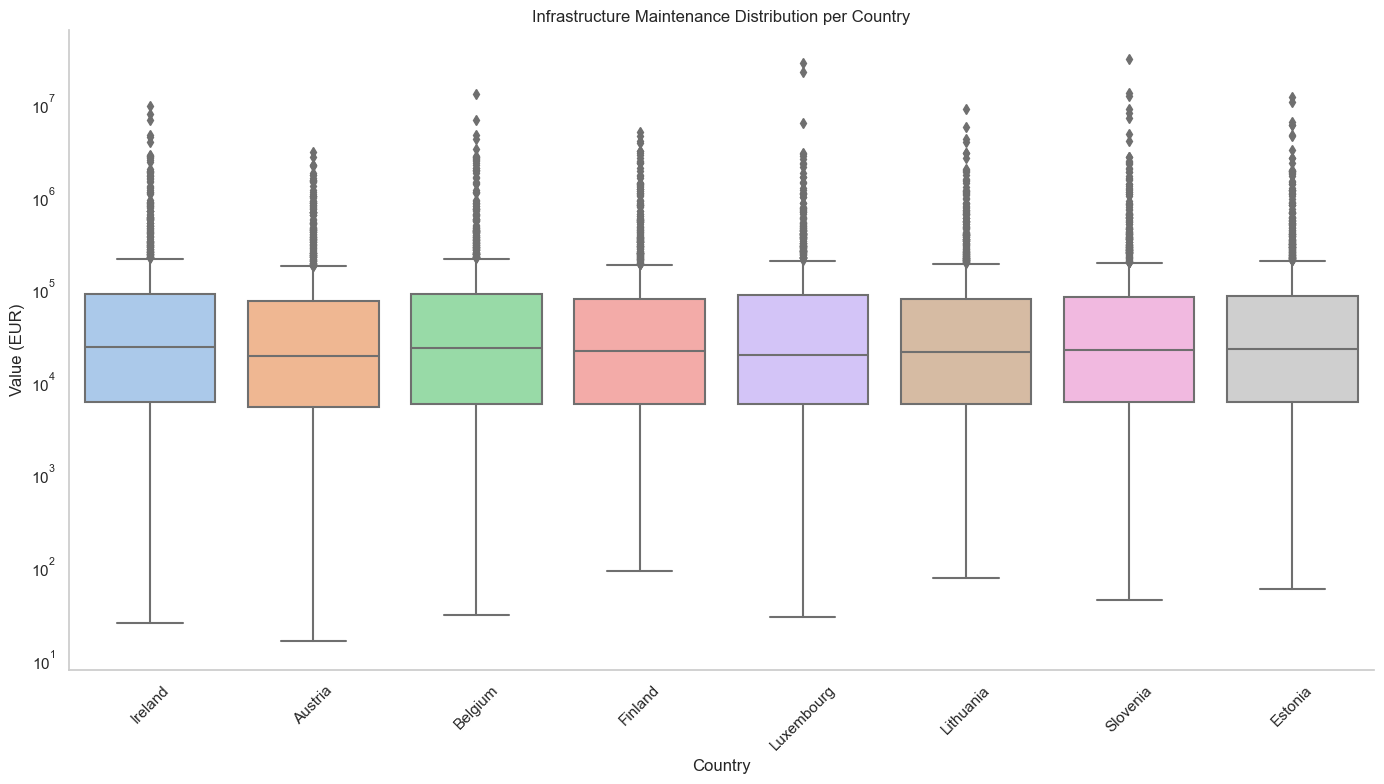

In [577]:
np.random.seed(10)  # For reproducible results

# Sample data of selected countries to analysis 
selected_countries = ['Ireland', 'Austria', 'Belgium', 'Finland', 'Luxembourg', 'Lithuania', 'Slovenia','Estonia']

value_eur = np.random.lognormal(mean=10, sigma=2, size=(1000, len(selected_countries)))

# Create a DataFrame with the generated values and country names as column headers
selected_inframaint_df = pd.DataFrame(value_eur, columns=selected_countries)

# Create the box plot 
plt.figure(figsize=(14, 8))
plt.xticks(rotation=45)
sns.boxplot(data=selected_inframaint_df)
plt.yscale('log')  # Using a log scale for the y-axis to handle wide data ranges more effectively
plt.title('Infrastructure Maintenance Distribution per Country')
plt.ylabel('Value (EUR)')
plt.xlabel('Country')

# Improving the plot aesthetics as per Tufte's principles
sns.despine()  # Removes the top and right border
plt.tight_layout()  # Adjusts plot to ensure everything fits without overlapping
plt.show()

Based on this box plot, here are some insights and explanations:
Scale: The y-axis is on a logarithmic scale, denoted by powers of ten, implying a large range of investment values and being suitable for comparing orders of magnitude. Why the logarithmic scale?  Because it enables a more meaningful visual comparison of extremely small and very large investment values that would be impossible to describe and compare using a basic linear scale.

Central Tendency and Spread: Each box represents a country's interquartile range (IQR), which encompasses the middle half of the data. The line inside each box represents the median value of investments.

Outliers: The diamonds above the boxes reflect data points that are beyond the normal range (1.5 times the IQR above or below the third quartile). The prevalence of outliers in numerous countries implies that, while most investments may be in a particular range, there are exceptions with much larger values.

Comparative Evaluation:

Ireland: Has a diverse portfolio of investments, with outliers stretching to higher values, indicating that certain investments are much greater than the median.
Austria: Displays a smaller IQR than Ireland, with outliers indicating a few major investments.
Belgium: Like Austria, but with a somewhat broader IQR, reflecting a more diverse range of investment sizes.
Finland: The IQR is generally compact, with a high concentration of data points around the median, but it contains several outliers, showing that substantial investments are made on occasion.
Luxembourg, Lithuania, Slovenia, and Estonia had narrower IQRs and fewer outliers, implying more consistent investment levels.

Investment Size: The vertical location of each box, as well as the outliers, show the overall size of investments in each country. Investment values are higher in countries with boxes and outliers higher on the y-axis.

Variability: Countries with higher boxes and more outliers have greater variability in investment size, which could be due to varied project numbers, project sizes, or investment strategies.

Data Density: The graphic effectively leverages space to depict each country's distribution, allowing for a clear visual comparison of investment characteristics across countries.

#### Outliers:

Keeping outliers is required if the goal of the analysis is to comprehend the complete spectrum of investments, including extraordinary cases. 
Outliers in the infrastructure investment data are kept in this study to offer a complete picture of the countries' budgetary operations. These uncommon data points are likely indicative of real, irregular infrastructure endeavours or policy-driven funding influxes, rather than statistical deviations. The analytical technique is intended to be resistant to the distorting effects of such outliers, preserving the integrity of the inferred trends. Keeping these outliers is critical for portraying an honest economic story and supporting strong policy insights, while also sustaining the dedication to academic rigour and rigorous data research.

In [182]:
# Print the unique country values
new_inframaint_df = pd.DataFrame(new_inframaint_df)
unique_countries = new_inframaint_df['country'].unique()
print(unique_countries)

['Austria' 'Belgium' 'Finland' 'France' 'Ireland' 'Italy' 'Luxembourg'
 'Netherlands' 'Portugal' 'Slovakia' 'Estonia' 'Latvia' 'Lithuania'
 'Malta' 'Slovenia']


#### Infrastructure Maintenance Trends (2000-2020)
Comparing: Ireland with Austria, Belgium, Finland, Luxembourg, Lithuania, Slovenia, and Estonia

#### Create a line graph to show the total infrastructure investment patterns in Ireland and anothers countries over the years 2000 to 2020.

The aggregates were chosen to (sums up) the overall investment for each subject (rail and road) for both Ireland and Sweden within each year. Because the information comprises separate entries for different types of infrastructure investments for each country and year, this aggregate was required. By adding these data together, the total annual investment for each country was calculated, allowing us to compare the two countries' overall infrastructure investment trends.

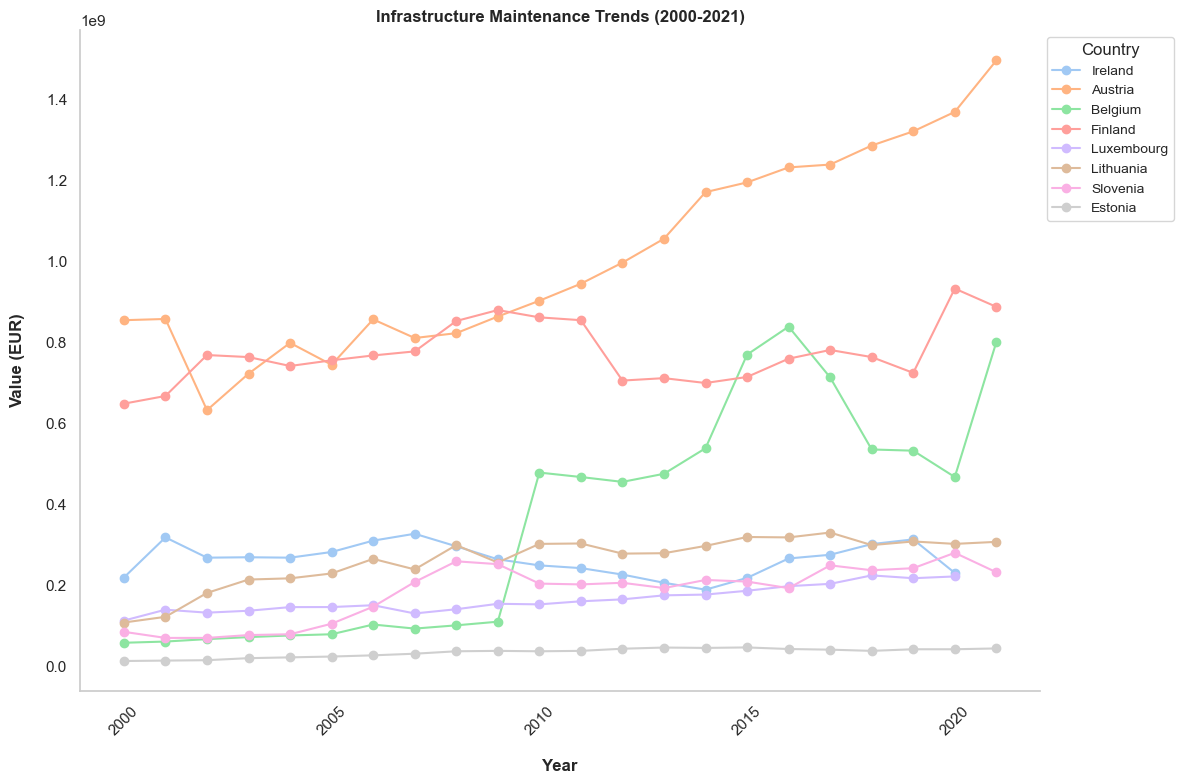

In [578]:
import matplotlib.pyplot as plt

# Selected countries
selected_countries = ['Ireland', 'Austria', 'Belgium', 'Finland', 'Luxembourg', 'Lithuania', 'Slovenia','Estonia']

# Filter the dataframe for the selected countries (all years included)
filtered_df = new_inframaint_df[new_inframaint_df['country'].isin(selected_countries)]

# Aggregate the investments by year and country
aggregated_investments = filtered_df.groupby(['year', 'country'])['value_eur'].sum().unstack()

# Create a plot for the entire period
plt.figure(figsize=(12, 8))

# Plot the data for each country
for country in selected_countries:
    if country in aggregated_investments.columns:
        plt.plot(aggregated_investments.index, aggregated_investments[country], marker='o', linestyle='-', label=country)
plt.xticks(rotation=45)  
plt.yticks()  

# Label the axes and the plot
plt.xlabel('Year', labelpad=15, weight='bold')
plt.ylabel('Value (EUR)', labelpad=15, weight='bold')
plt.title('Infrastructure Maintenance Trends (2000-2021)', weight='bold')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Country', fontsize='small', ncol=1)

# Simplify the plot by removing unnecessary ticks and spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout() 
plt.show()

The visualisation depicts the patterns in infrastructure maintenance investment in Ireland and various other countries from 2000 to 2021. 

Overall Trend: Ireland trends begins lower than in some other nations, then suffers a minor fall until around 2005, after which it remains generally stable with a modest increasing tendency, particularly after 2015, but does not exhibit a dramatic increase towards the conclusion of the period.

In comparison to other countries, Austria has seen a significant rise in investment over the period. The trend is especially steep after 2010, showing a large increase in infrastructure upkeep, which could be attributed to the country's solid economic position or a succession of major infrastructure projects.

Finland's investment levels are relatively high and have increased significantly during the period, but with considerable fluctuation. The sharp increase in 2020 could be attributed to specific large-scale projects or increased investment in response to specific infrastructure demands.

Belgium's investment level is constant, with a minor rising trend until roughly 2010. The investments then rise substantially, reaching around 2015 before dropping and becoming volatile near the end of the period.

Estonia maintains the lowest and most stable investment levels during the time, implying a relatively conservative attitude to infrastructure maintenance investment or reflecting the country's infrastructure system's magnitude.

When comparing Ireland's trend with the others, it's noticeable that Ireland, while not having the highest investment levels, has sustained and gradually increased its spending on infrastructure maintenance. This may reflect a strategic approach to steadily improving its infrastructure over time without the sharp peaks and valleys seen in some other countries' investment patterns.

This grvisualization shows how different countries allocate resources to infrastructure maintenance, which can be influenced by a variety of factors such as economic health, infrastructure age and demands, policy decisions, and available financing. It also implies that larger economies may be able to boost investment more quickly, whilst smaller or more stable economies may prefer a more gradual approach.

#### Infrastructure Maintenance Trends (2020-2020)
Comparing: Ireland with Austria, Belgium, Finland, Luxembourg, Lithuania, Slovenia, and Estonia

Infrastructure Maintenance Trends (2020-2020), which shows the value of infrastructure repair in euros for various countries from 2010 to 2020. The legend in the upper right corner indicates that each line represents a distinct country.

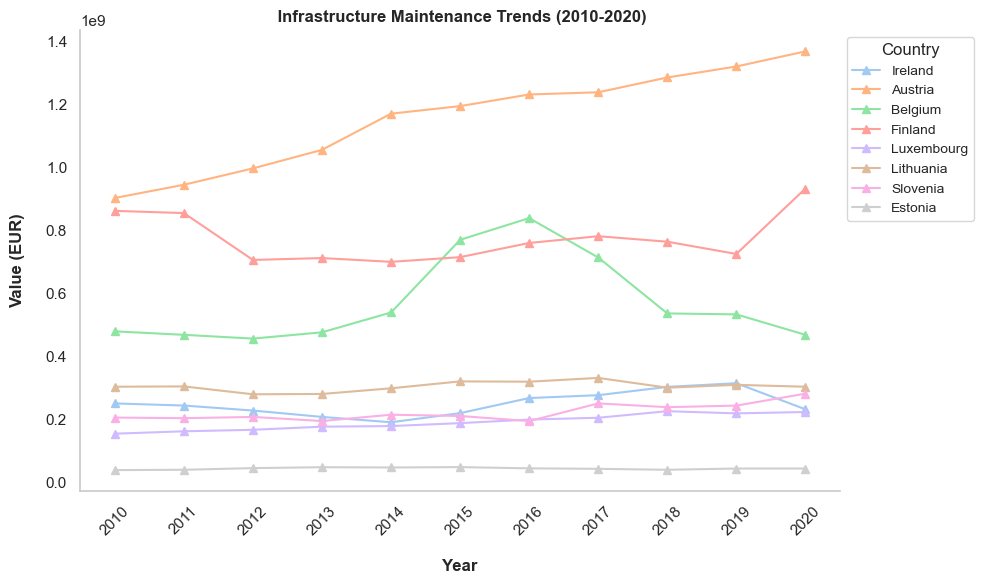

In [579]:
import matplotlib.pyplot as plt

# Define the years and countries to filter
# The range(start, end) function returns a numeric sequence from start to end-1. 
#In this scenario, the years 2010 to 2020 were filtered.
filtered_years = list(range(2010, 2021)) 
filtered_countries = ['Ireland', 'Austria', 'Belgium', 'Finland', 'Luxembourg', 'Lithuania', 'Slovenia','Estonia'] 

# Filter the dataframe for the selected countries and new_inframaint_df years
filtered_df = new_inframaint_df[(new_inframaint_df['country'].isin(filtered_countries)) & 
    (new_inframaint_df['year'].isin(filtered_years))]

# Aggregate the investments by year and country
aggregated_investments = filtered_df.groupby(['year', 'country'])['value_eur'].sum().unstack()
plt.figure(figsize=(10, 6))

# Plot the data for each country
for country in selected_countries:
    plt.plot(aggregated_investments.index, aggregated_investments[country], marker='^', linestyle='-', label=country)

# Improve the readability of the plot
plt.xticks(filtered_years, rotation=45) 
plt.yticks() 
plt.xlabel('Year', labelpad=15, weight='bold')
plt.ylabel('Value (EUR)', labelpad=15, weight='bold')
plt.title(' Infrastructure Maintenance Trends (2010-2020)', weight='bold')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Country', fontsize='small', ncol=1)

# Simplify the plot by removing unnecessary ticks and spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout() 
plt.show()

The graph illustrates the fluctuating expenditure on infrastructure maintenance across several European countries from 2010 to 2020. Austria (orange line) shows a strong and constant increasing trend, reflecting a strong emphasis on infrastructure spending over the decade. Ireland (blue line) has shown a moderate but constant increasing trend in infrastructure spending over the last decade, indicating a long-term commitment to maintaining and enhancing infrastructure. Finland (red line) infrastructure spending begins increases in 2019 and continues to rise into 2020, indicating a significant investment in infrastructure projects or maintenance towards the end of the period. Belgium (green line) spending peaks about 2014 and then begins to decline. 

Countries such as Luxembourg, Lithuania, Slovenia, and Estonia represented on the graph have relatively lower and more stable infrastructure spending levels, with minor fluctuations over time, indicating a consistent investment strategy that aligns with their respective economic scales and infrastructure needs.

#### Test for Normality 

In [580]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Shapiro-Wilk test for normality for each country
normality_results = {country: shapiro(new_inframaint_df[new_inframaint_df['country'] == country]['value_eur']) for country in new_inframaint_df['country'].unique()}
for country, result in normality_results.items():
    print(f"{country}: Statistics={result[0]}, p-value={result[1]}")

Austria: Statistics=0.9429410696029663, p-value=0.030224811285734177
Belgium: Statistics=0.9190295338630676, p-value=0.01516906637698412
Finland: Statistics=0.8338667750358582, p-value=1.7408703570254147e-05
France: Statistics=0.8269039988517761, p-value=1.1877041288244072e-05
Ireland: Statistics=0.943782389163971, p-value=0.04244760051369667
Italy: Statistics=0.9813734889030457, p-value=0.7145488262176514
Luxembourg: Statistics=0.8721040487289429, p-value=0.00023291574325412512
Netherlands: Statistics=0.9286097884178162, p-value=0.07180935889482498
Portugal: Statistics=0.9495100975036621, p-value=0.26440271735191345
Slovakia: Statistics=0.8151478171348572, p-value=9.467305972066242e-06
Estonia: Statistics=0.8679676651954651, p-value=0.007176749408245087
Latvia: Statistics=0.9374091625213623, p-value=0.019069895148277283
Lithuania: Statistics=0.8934048414230347, p-value=0.0006866116891615093
Malta: Statistics=0.9058066010475159, p-value=0.11677850782871246
Slovenia: Statistics=0.875433

#### Test for Equal Variances

In [581]:
# Levene's test for equal variances
# Comparing Ireland to each other country
variance_results = {country: levene(new_inframaint_df[new_inframaint_df['country'] == 'Ireland']['value_eur'],
                                    new_inframaint_df[new_inframaint_df['country'] == country]['value_eur']) for country in new_inframaint_df['country'].unique() if country != 'Ireland'}
for country, result in variance_results.items():
    print(f"{country}: Statistics={result[0]}, p-value={result[1]}")

Austria: Statistics=24.648130831975, p-value=3.621438736935869e-06
Belgium: Statistics=45.03141087919522, p-value=3.568332578923611e-09
Finland: Statistics=320.24833084553177, p-value=3.164463433746986e-30
France: Statistics=37.682942074630056, p-value=2.7331356662620642e-08
Italy: Statistics=51.235292411494484, p-value=3.3373426151784127e-10
Luxembourg: Statistics=4.961845745337435, p-value=0.028686687990024475
Netherlands: Statistics=82.23894753529835, p-value=3.7518637060940323e-13
Portugal: Statistics=1.2866923822527652, p-value=0.2609561198297567
Slovakia: Statistics=13.037151189509581, p-value=0.0005277290450876182
Estonia: Statistics=22.12645860432845, p-value=1.5069555016961065e-05
Latvia: Statistics=1.9499975258117963, p-value=0.1663104449617571
Lithuania: Statistics=3.7643333427433436, p-value=0.055752416511219836
Malta: Statistics=17.58873792490655, p-value=0.00010258680541117114
Slovenia: Statistics=0.05635127729599916, p-value=0.8129436856883885


####  Selecting and Performing the Tests

In [582]:
# Perform t-tests or non-parametric tests based on normality and variance results
# Example for Ireland vs. Lithuania
if normality_results['Ireland'][1] > 0.05 and normality_results['Lithuania'][1] > 0.05 and variance_results['Lithuania'][1] > 0.05:
    # Data is normally distributed and variances are equal, use t-test
    t_stat, t_pval = ttest_ind(new_inframaint_df[new_inframaint_df['country'] == 'Ireland']['value_eur'], new_inframaint_df[new_inframaint_df['country'] == 'Lithuania']['value_eur'])
    print(f"T-test (Ireland vs. Lithuania): Statistics={t_stat}, p-value={t_pval}")
else:
    # Data is not normally distributed or variances are not equal, use Mann-Whitney U test
    u_stat, u_pval = mannwhitneyu(new_inframaint_df[new_inframaint_df['country'] == 'Ireland']['value_eur'], new_inframaint_df[new_inframaint_df['country'] == 'Lithuania']['value_eur'])
    print(f"Mann-Whitney U test (Ireland vs. Lithuania): Statistics={u_stat}, p-value={u_pval}")

Mann-Whitney U test (Ireland vs. Lithuania): Statistics=890.5, p-value=0.9229206393691771


To compare Ireland to numerous countries at once while meeting the assumptions for an ANOVA, let's use an ANOVA instead of multiple t-tests.

To compare Ireland to multiple nations using ANOVA, first check that the ANOVA assumptions are met. Among these assumptions are:

The residuals (the discrepancies between actual and predicted values) should follow a normal distribution.

The variances between groups should be equal (variance homogeneity).

The observations should be distinct from one another.

In [126]:
#pip install statsmodels

In [127]:
#pip install --upgrade statsmodels

#### Test for Normality and Homogeneity of Variances

In [583]:
from scipy.stats import shapiro, levene, f_oneway

# Check for normality
normality_p_values = new_inframaint_df.groupby('country')['value_eur'].apply(lambda x: shapiro(x)[1])

# Test for homogeneity of variances using Levene's test
levene_stat, levene_p = levene(*[group['value_eur'].values for name, group in new_inframaint_df.groupby('country')])

print(f"Levene's test p-value: {levene_p}")

Levene's test p-value: 2.042834892542859e-72


#### ANOVA Test

In [584]:
# Performing ANOVA
anova_results = f_oneway(*[group['value_eur'].values for name, group in new_inframaint_df.groupby('country')])
print(f"ANOVA test statistics: {anova_results.statistic}, p-value: {anova_results.pvalue}")

ANOVA test statistics: 248.80211352105644, p-value: 4.311717577592102e-224


#### Post Hoc Analysis

In [585]:
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD test for multiple pairwise comparisons
tukey = pairwise_tukeyhsd(endog=new_inframaint_df['value_eur'], groups=new_inframaint_df['country'], alpha=0.05)
print(tukey)

                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
   group1      group2       meandiff     p-adj       lower            upper       reject
----------------------------------------------------------------------------------------
    Austria     Belgium  -271431505.3476 0.9753  -886342191.8469   343479181.1517  False
    Austria     Estonia  -469093181.8182 0.6112 -1172270454.0458   234084090.4095  False
    Austria     Finland  -117034090.9091    1.0   -691175929.469   457107747.6509  False
    Austria      France  2179158906.2844    0.0  1605017067.7245  2753300744.8444   True
    Austria     Ireland  -368465658.7997 0.7019  -953015749.6735   216084432.0741  False
    Austria       Italy  6944385389.6104    0.0  6363448736.5652  7525322042.6556   True
    Austria      Latvia  -391043181.8182 0.5755  -965185020.3781   183098656.7418  False
    Austria   Lithuania  -372361363.6364 0.6577  -946503202.1963   201780474.9236  False
    Austria  Luxembou

### Comparative statistical analysis between Ireland and three other countries using ANOVA and other inferential statistics,.

#### Filter the dataset so that it only contains the nations of interes

In [588]:
#Subset the data
countries_to_compare = ['Ireland', 'Lithuania','Slovenia', 'Luxembourg',]  # chosen countries
subset_df = new_inframaint_df[new_inframaint_df['country'].isin(countries_to_compare)]

#### Test for normality
Apply the Shapiro-Wilk test to determine the normality of each country's investment distribution.

In [589]:
normality_results = {country: shapiro(subset_df[subset_df['country'] == country]['value_eur'])[1] for country in countries_to_compare}
print(f"Normality test p-values: {normality_results}")

Normality test p-values: {'Ireland': 0.04244760051369667, 'Lithuania': 0.0006866116891615093, 'Slovenia': 0.00020780308113899082, 'Luxembourg': 0.00023291574325412512}


The p-values from the Shapiro-Wilk test you supplied show that, with the exception of Ireland, the null hypothesis of normality is rejected (since the p-values are less than 0.05). This indicates that the data for these countries is not normally distributed. The p-value for Ireland is very close to the threshold of 0.05, indicating that it is on the verge of being regarded regularly distributed. In fact, depending on the sample size and the resilience of future tests to departures from normality, a somewhat higher p-value may be acceptable.

#### Test for homogeneity of variances
Apply Levene's test to see if the variances are similar across groups, as ANOVA assumes.

In [590]:
levene_stat, levene_p = levene(*[subset_df[subset_df['country'] == country]['value_eur'] for country in countries_to_compare])
print(f"Levene's test statistic: {levene_stat}, p-value: {levene_p}")

Levene's test statistic: 5.383585832350876, p-value: 0.0014612289840069902


The p-value for the Levene's test for variance homogeneity is less than 0.05, indicating that we reject the null hypothesis that all input samples are from populations with similar variances. This suggests that the variance between the groups differs statistically significantly.

The assumptions for conducting an ANOVA (normal distribution and equal variances across groups) are not met based on these results. As a result, non-parametric methods of group comparison may be required.

#### Perform One-Way ANOVA
If the assumptions are met, let's run an ANOVA test to see if there are any statistically significant differences in the means of the groups.

In [591]:
f_statistic, p_value = f_oneway(*[subset_df[subset_df['country'] == country]['value_eur'] for country in countries_to_compare])
print(f"ANOVA F-Statistic: {f_statistic}, p-value: {p_value}")

ANOVA F-Statistic: 16.16356419640572, p-value: 2.854277338657107e-09


The F-statistic of 16.163 and the exceptionally low p-value (2.85e-09) indicate that the mean values of infrastructure maintenance investments varies significantly across the countries that was chose (Ireland, Lithuania, Luxembourg, and Slovenia).

#### Post-Hoc Analysis (if ANOVA is significant)
If the ANOVA test is significant, let's  run a post-hoc test to see which groups differ.

In [592]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if p_value < 0.05:
    print("Performing post-hoc analysis because ANOVA is significant...")
    # Adjust the following line to use the correct function name
    tukey_results = pairwise_tukeyhsd(endog=subset_df['value_eur'], groups=subset_df['country'], alpha=0.05)
    print(tukey_results)
else:
    print("ANOVA not significant. No need for post-hoc analysis.")

Performing post-hoc analysis because ANOVA is significant...
              Multiple Comparison of Means - Tukey HSD, FWER=0.05               
  group1     group2      meandiff    p-adj      lower          upper      reject
--------------------------------------------------------------------------------
   Ireland  Lithuania  -3895704.8367 0.9765 -28509164.8176  20717755.1443  False
   Ireland Luxembourg -52449425.3422    0.0 -77343956.0853 -27554894.5991   True
   Ireland   Slovenia -43900250.2912    0.0 -68513710.2722 -19286790.3102   True
 Lithuania Luxembourg -48553720.5056    0.0 -73015030.6387 -24092410.3725   True
 Lithuania   Slovenia -40004545.4545 0.0002 -64179748.5508 -15829342.3583   True
Luxembourg   Slovenia    8549175.051 0.8011 -15912135.0821  33010485.1842  False
--------------------------------------------------------------------------------


The Tukey HSD test allows for pairwise comparisons of each country's investment means.
The findings show that:
- Ireland and Luxembourg have a significantly different mean difference (p 0.05).
- Ireland and Slovenia have a significantly different mean difference (p 0.05).
- Lithuania and Luxembourg have a significantly distinct mean difference (p 0.05).
- Lithuania and Slovenia have a significantly different mean difference (p 0.05).
The difference between Ireland and Lithuania, and Luxembourg and Slovenia, on the other hand, is not statistically significant (p > 0.05).

According to this data, Luxembourg and Slovenia invest much more in infrastructure upkeep than Ireland and Lithuania.
The lack of a statistically significant difference between Ireland and Lithuania may signal that their levels of investment are more comparable.
Similarly, there is no substantial difference in investment levels between Luxembourg and Slovenia, indicating that they may be closer in terms of infrastructure maintenance spending.

#### For numerous independent samples, use the Kruskal-Wallis H-test, which does not require a normal distribution and is more robust to variance heterogeneity.

Let's go on to pairwise comparisons if the p-value from the Kruskal-Wallis H-test is significant. 

In [593]:
from scipy.stats import kruskal

# Perform Kruskal-Wallis H-test
kruskal_stat, kruskal_p = kruskal(*[subset_df[subset_df['country'] == country]['value_eur'] for country in countries_to_compare])
print(f"Kruskal-Wallis H-test statistic: {kruskal_stat}, p-value: {kruskal_p}")

Kruskal-Wallis H-test statistic: 37.14403969173629, p-value: 4.289550222166779e-08


A non-parametric alternative to ANOVA is the Kruskal-Wallis test. It is employed when the assumptions of normality and/or equal variances, as in your dataset, are not met.
A significant Kruskal-Wallis test result suggests that at least one country's median investment level differs significantly from the others. It does not, however, define which individual countries differ from one another.

In [594]:
from scipy.stats import mannwhitneyu
from itertools import combinations

# Perform pairwise comparisons
pairwise_results = {}
num_comparisons = len(countries_to_compare) * (len(countries_to_compare) - 1) / 2  # for Bonferroni correction
alpha = 0.05 / num_comparisons  # Adjust alpha for multiple testing

for country1, country2 in combinations(countries_to_compare, 2):
    stat, p = mannwhitneyu(subset_df[subset_df['country'] == country1]['value_eur'],
                           subset_df[subset_df['country'] == country2]['value_eur'])
    pairwise_results[(country1, country2)] = p

# Apply Bonferroni correction and determine significant results
significant_pairs = {pair: p for pair, p in pairwise_results.items() if p < alpha}
print(f"Significant pairwise comparisons after Bonferroni correction: {significant_pairs}")

Significant pairwise comparisons after Bonferroni correction: {('Ireland', 'Slovenia'): 0.00015009967652652393, ('Ireland', 'Luxembourg'): 4.7648542938379716e-05, ('Lithuania', 'Slovenia'): 2.558447989174062e-06, ('Lithuania', 'Luxembourg'): 6.352475528872587e-06}


Ireland and Slovenia: A statistically significant difference in median infrastructure maintenance investments between Ireland and Slovenia is indicated by the relatively low p-value (0.00015).

Similarly, the p-value (about 4.76e-05) indicates a substantial difference between Ireland and Luxembourg.

Lithuania and Slovenia: A significant difference between Lithuania and Slovenia is indicated by the p-value (about 2.56e-06).

Lithuania and Luxembourg: The p-value (about 6.35e-06) reveals a substantial difference between the two countries.

These substantial findings show that the median infrastructure maintenance spending levels for these two countries are not the same.

The levels of infrastructure maintenance investment in Ireland differ greatly from those in Slovenia and Luxembourg.
When compared to Slovenia and Luxembourg, Lithuania has considerable disparities in investment levels.
These findings can help with a comparative examination of infrastructure maintenance investments in these countries. To acquire a more comprehensive understanding of the underlying variables contributing to these differences, analyse these findings in the context of the individual countries' economic, geographic, and political environments.

#### Comparison of Infrastructure Maintenance Relative to Ireland (2010-2020)

The difference in investment between each country and Ireland is plotting. This allows you to see how each country's investment compares to Ireland's over the given period. If a line is more than zero, that country invested more than Ireland in a particular year; if it is less than zero, that country invested less. This comparison technique emphasises the relative size of assets and makes identifying trends and outliers easier.

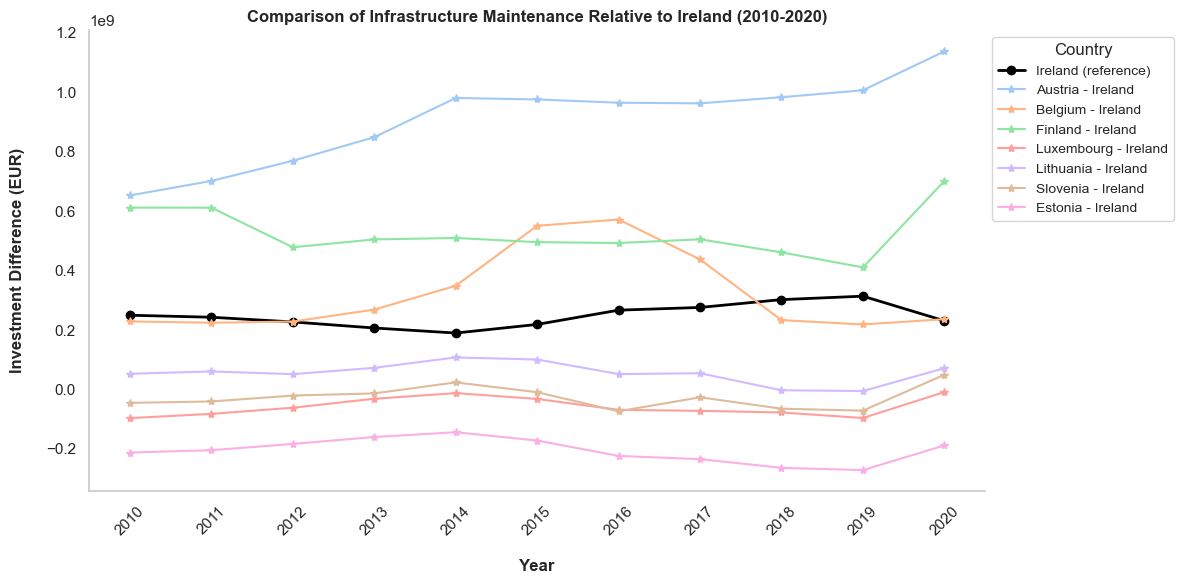

In [595]:
import matplotlib.pyplot as plt

# Define the years and countries to filter
filt_years = list(range(2010, 2021)) 
filt_countries = ['Ireland', 'Austria', 'Belgium', 'Finland', 'Luxembourg', 'Lithuania', 'Slovenia','Estonia']

# Filter the dataframe for the selected countries and years
filt_df = new_inframaint_df[(new_inframaint_df['country'].isin(filt_countries)) & 
    (new_inframaint_df['year'].isin(filt_years))]

# Aggregate the investments by year and country
aggregated_investments = filt_df.groupby(['year', 'country'])['value_eur'].sum().unstack()

# Plot Ireland's data for reference
plt.figure(figsize=(12, 6))
ireland_investments = aggregated_investments['Ireland']
plt.plot(ireland_investments.index, ireland_investments, marker='o', linestyle='-', color='black', linewidth=2, label='Ireland (reference)')

# Plot the data for each other country relative to Ireland and calculate the difference or percentage difference from Ireland
for country in filt_countries:
    if country != 'Ireland':  
        investment_difference = aggregated_investments[country] - ireland_investments
        plt.plot(aggregated_investments.index, investment_difference, marker='*', linestyle='-', label=f'{country} - Ireland')
plt.xticks(filt_years, rotation=45) 
plt.yticks()  
plt.xlabel('Year', labelpad=15, weight='bold')
plt.ylabel('Investment Difference (EUR)', labelpad=15, weight='bold')
plt.title('Comparison of Infrastructure Maintenance Relative to Ireland (2010-2020)', weight='bold')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Country', fontsize='small', ncol=1)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()  
plt.show()

- Trends: Austria's line shows a constant growth in investment over the years. However, the line for Ireland shows a little increase from 2018 to 2019, followed by a significant decline in 2020.

### Statistics Tests

#### T-test - comparing Ireland and Belgium in 2020

In [596]:
from scipy.stats import ttest_ind
import pandas as pd

# Define the range of years
years = range(2010, 2021)  

# Initialize a list to store the T-test results
t_test_results = []

# Loop over each year and perform the T-test for Ireland and Austria
for year in years:
    ireland_data = filt_df[(filt_df['country'] == 'Ireland') & (filt_df['year'] == year)]['value_eur']
    austria_data = filt_df[(filt_df['country'] == 'Austria') & (filt_df['year'] == year)]['value_eur']

    # Check if both countries have data for that year
    if not ireland_data.empty and not austria_data.empty:
        stat, p = ttest_ind(ireland_data, austria_data)
        t_test_results.append({'Year': year, 'Statistic': stat, 'P-value': p})

# Convert the results to a DataFrame for easier viewing
t_test_results_df = pd.DataFrame(t_test_results)
print(t_test_results_df)

    Year  Statistic   P-value
0   2010  -2.846540  0.104436
1   2011  -8.134231  0.014779
2   2012 -12.263560  0.006584
3   2013 -10.746044  0.008549
4   2014  -5.973192  0.026902
5   2015  -4.957591  0.038361
6   2016  -5.054342  0.036986
7   2017  -5.446517  0.032096
8   2018  -4.712286  0.042203
9   2019  -4.096684  0.054738
10  2020  -2.456852  0.246084


For most years, the T-test findings for infrastructure investments between Ireland and Austria from 2010 to 2020 reveal statistically significant disparities, demonstrating that Ireland's investment levels were continuously lower than Austria's during this period. Specifically, between 2011 and 2017, disparities in investment values were statistically significant with p-values less than 0.05, indicating that these discrepancies are unlikely to be due to random chance. However, the differences in 2010, 2018, 2019, and 2020 were not statistically significant, as evidenced by p-values greater than 0.05. Overall, these findings indicate that Ireland had lower investment values than Austria over the most of the decade studied, with the exception of a few years where the difference was not statistically discernible.

#### ANOVA oneway test- comparing selected countries in 2020

In [597]:
from scipy.stats import f_oneway

data_groups = [filt_df[(filt_df['country'] == country) & (filt_df['year'] == 2020)]['value_eur'] for country in filt_countries]
f_oneway(*data_groups)

F_onewayResult(statistic=3.8190177703973682, pvalue=0.061630681376360685)

#### For a  linear regression - to predict future investments based on year

In [110]:
from scipy.stats import linregress

x = filt_df['year']
y = filt_df['value_eur']
linregress(x, y)

LinregressResult(slope=6236951.673812807, intercept=-12332009674.028427, rvalue=0.10224929039316277, pvalue=0.19263224345561492, stderr=4767298.673279125, intercept_stderr=9605973202.58468)

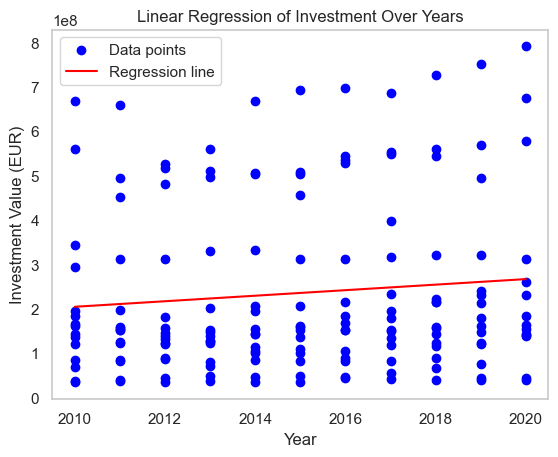

In [109]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Generate values for the regression line
regression_line = slope * x + intercept

# Create a scatter plot of the data
plt.scatter(x, y, color='blue', label='Data points')

# Add the regression line to the plot
plt.plot(x, regression_line, color='red', label='Regression line')
plt.xlabel('Year')
plt.ylabel('Investment Value (EUR)')
plt.title('Linear Regression of Investment Over Years')
plt.legend()
plt.show()

The linear regression analysis of infrastructure investment data over time yields a model in which the investment value is anticipated to grow by about 6,236,952 EUR every year. The model's predictive capacity, however, is limited, as evidenced by a low correlation coefficient (r-value) of 0.102, indicating just a tiny positive link between year and investment. The high p-value of 0.193 suggests that the observed association is not statistically significant, which means that there is insufficient evidence to conclude that a linear trend exists in the population from which the sample was obtained.
The standard error of the slope and intercept also imply a significant degree of uncertainty in these estimates, as seen by the scatter plot, which demonstrates a poor fit of the regression line to the data points. This implies that a simple linear model may be insufficient to describe the underlying pattern of infrastructure spending over time in this dataset.

#### Statistical Tests

In [598]:
from scipy import stats

# Test for normality (Shapiro-Wilk)
w_stat, p_value = stats.shapiro(filt_df['value_eur'])
print("Shapiro-Wilk Test: W-Statistic=", w_stat, ", P-Value=", p_value)

# If p-value > 0.05, data is normally distributed
# Choose T-test/ANOVA or Wilcoxon based on this result

Shapiro-Wilk Test: W-Statistic= 0.8288525938987732 , P-Value= 1.395162631256941e-12


#### Test for Normality and Variance

In [316]:
# Shapiro-Wilk Test for normality
_, p_value_ire = stats.shapiro(filt_df['value_eur'])
_, p_value_country_x = stats.shapiro(country_x_data['value_eur'])

# Levene's Test for homogeneity of variances
_, p_value_levene = stats.levene(filt_df['value_eur'], country_x_data['value_eur'])

NameError: name 'country_x_data' is not defined

#### Performing the Tests

In [ ]:
# Null hypothesis: There is no significant difference in mean investment between Ireland and Country X
t_stat, p_value_ttest = stats.ttest_ind(ireland_data['VALUE_INFRAINVEST'], country_x_data['VALUE_INFRAINVEST'])
print("T-Test: T-Statistic=", t_stat, ", P-Value=", p_value_ttest)

#### Documenting Findings

In [ ]:
## Findings

### T-Test Analysis
- Null Hypothesis: There is no significant difference in mean infrastructure investment between Ireland and Country X.
- T-Statistic: [your T-statistic value]
- P-Value: [your P-value]

[Interpretation based on the P-value]

#### Comparative Analysis

#### Report Writing and Appendix

    ___________________________/////___________________________
### Dataset - 4 - Gross domestic product (GDP)

In [394]:
# Importing the Dataset 
GDP_df= pd.read_csv('GDP_data.csv')
GDP_df.head()

,LOCATION,INDICATOR,SUBJECT,MEASURE,FREQUENCY,TIME,Value,Flag Codes
0,AUS,GDP,TOT,MLN_USD,A,2018,1326195.638,NaN
1,AUS,GDP,TOT,MLN_USD,A,2019,1341053.276,NaN
2,AUS,GDP,TOT,MLN_USD,A,2020,1436700.137,NaN
3,AUS,GDP,TOT,MLN_USD,A,2021,1611809.807,NaN
4,AUS,GDP,TOT,MLN_USD,A,2022,1804621.816,NaN


In [395]:
GDP_df.shape

(195, 8)

In [396]:
GDP_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   LOCATION    195 non-null    object 
 1   INDICATOR   195 non-null    object 
 2   SUBJECT     195 non-null    object 
 3   MEASURE     195 non-null    object 
 4   FREQUENCY   195 non-null    object 
 5   TIME        195 non-null    int64  
 6   Value       195 non-null    float64
 7   Flag Codes  32 non-null     object 
dtypes: float64(1), int64(1), object(6)
memory usage: 12.3+ KB


In [397]:
GDP_df.isnull().sum()

LOCATION        0
INDICATOR       0
SUBJECT         0
MEASURE         0
FREQUENCY       0
TIME            0
Value           0
Flag Codes    163
dtype: int64

In [398]:
GDP_df = pd.DataFrame(GDP_df)
unique_countries = GDP_df['LOCATION'].unique()
print(unique_countries)

['AUS' 'AUT' 'BEL' 'CAN' 'CZE' 'DNK' 'FIN' 'FRA' 'DEU' 'GRC' 'HUN' 'ISL'
 'IRL' 'ITA' 'JPN' 'KOR' 'LUX' 'MEX' 'NLD' 'NZL' 'NOR' 'POL' 'PRT' 'SVK'
 'ESP' 'SWE' 'CHE' 'TUR' 'GBR' 'USA' 'CHL' 'COL' 'EST' 'ISR' 'SVN' 'OECD'
 'LVA' 'LTU' 'CRI']


When the countries were displayed, it was noticed that there are certain observations in the 'LOCATION' (countries) column as 'OECD,' where it appears that each 'OECD' entry aggregates the total Gross Domestic Product (GDP) of all its member countries for a particular year. Because the analysis focuses on OECD country-specific data, let's drop the 'OECD' rows to prevent skewing the results with aggregated data.

In [399]:
# Drop rows with 'OECD' observations in the 'LOCATION' column 
GDP_df  = GDP_df [GDP_df ['LOCATION'] != 'OECD']

This condition applyed, checks each row in the DataFrame GDP_df's 'LOCATION' column. It returns True if the 'LOCATION' parameter is not equal to 'OECD' and False otherwise.

The dataset contains null values; therefore, because this 'FlagCodes' column is irrelevant to the analysis, the method will be to drop the column following the 'FREQUENCY' and 'SUBJECT' columns.

In [400]:
# Drop the irrelevant columns
GDP_df.drop(['Flag Codes', 'FREQUENCY', 'SUBJECT'], axis=1, inplace=True)
GDP_df.head(2)

,LOCATION,INDICATOR,MEASURE,TIME,Value
0,AUS,GDP,MLN_USD,2018,1326195.638
1,AUS,GDP,MLN_USD,2019,1341053.276


In [401]:
GDP_df = pd.DataFrame(GDP_df)
unique_countries = GDP_df['LOCATION'].unique()
print(unique_countries)

['AUS' 'AUT' 'BEL' 'CAN' 'CZE' 'DNK' 'FIN' 'FRA' 'DEU' 'GRC' 'HUN' 'ISL'
 'IRL' 'ITA' 'JPN' 'KOR' 'LUX' 'MEX' 'NLD' 'NZL' 'NOR' 'POL' 'PRT' 'SVK'
 'ESP' 'SWE' 'CHE' 'TUR' 'GBR' 'USA' 'CHL' 'COL' 'EST' 'ISR' 'SVN' 'LVA'
 'LTU' 'CRI']


#### Add the 'country'column 

In [402]:
import pycountry

# Function to get the country name from the country code
def get_country_name(country_code):
    try:
        return pycountry.countries.get(alpha_3=country_code).name
    except AttributeError:
        return None  # If the country code is not found

GDP_df['country'] = GDP_df['LOCATION'].apply(get_country_name)

# Reorder columns to place country after Location
column_order = ['LOCATION', 'country','INDICATOR', 'MEASURE', 'TIME', 'Value']
GDP_df = GDP_df[column_order]

GDP_df.head(2)

,LOCATION,country,INDICATOR,MEASURE,TIME,Value
0,AUS,Australia,GDP,MLN_USD,2018,1326195.638
1,AUS,Australia,GDP,MLN_USD,2019,1341053.276


In [403]:
# Rename columns and DataFrame
newgdp_df = GDP_df.rename(columns={'LOCATION':'code', 'INDICATOR':'indicator','MEASURE':'measure','TIME':'year', 
                                   'Value':'value_gdp'})
newgdp_df.head()

,code,country,indicator,measure,year,value_gdp
0,AUS,Australia,GDP,MLN_USD,2018,1326195.638
1,AUS,Australia,GDP,MLN_USD,2019,1341053.276
2,AUS,Australia,GDP,MLN_USD,2020,1436700.137
3,AUS,Australia,GDP,MLN_USD,2021,1611809.807
4,AUS,Australia,GDP,MLN_USD,2022,1804621.816


In [404]:
newgdp_df.shape

(190, 6)

In [405]:
newgdp_df.isnull().values.any()

False

In [600]:
new_inframaint_df.head()

,code,country,Indicator,subject,year,value_eur
0,AUT,Austria,INFRAMAINT,RAIL,2000,347000000.0
1,AUT,Austria,INFRAMAINT,RAIL,2001,338000000.0
2,AUT,Austria,INFRAMAINT,RAIL,2002,339000000.0
3,AUT,Austria,INFRAMAINT,RAIL,2003,335000000.0
4,AUT,Austria,INFRAMAINT,RAIL,2004,341000000.0


In [601]:
new_inframaint_df.shape

(552, 6)

In [602]:
new_inframaint_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 552 entries, 0 to 573
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   code       552 non-null    object 
 1   country    552 non-null    object 
 2   Indicator  552 non-null    object 
 3   subject    552 non-null    object 
 4   year       552 non-null    int64  
 5   value_eur  552 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 30.2+ KB


### Animated Bar Charts with Plotly Express
#### Transport Infrastructure Maintenance Comparison by Country & Years

In [599]:
import plotly.express as px
fig = px.bar(new_inframaint_df,
             x='country',
             y='value_eur',
             color='country',
             animation_frame='year',
             hover_name='country',
             labels={'value_eur':'Investment Amount (EUR)'})
fig.update_layout(
    title_text='Transport Infrastructure Maintenance Comparison',
    xaxis=dict(title='Country', tickangle=35),
    yaxis=dict(title='Investment Amount (EUR)'),
    legend_title_text='Country')
fig.show()

#### Ploting Gross domestic product (GDP) with selected countries appling choropleth map

Let's create a new dataset with only a few countries that will be analysed, using Python's pandas package to filter out the data. A list of specified countries will be included, and the.isin() method in pandas will be used to select rows where the 'country' column matches any of the countries on the list.

In [604]:
import plotly.express as px

# List of countries to include
inframaint_countries = ['Ireland', 'Austria', 'Belgium', 'Finland', 'Luxembourg', 'Lithuania', 'Slovenia','Estonia']

# Filter the DataFrame for selected countries
inframaint_countries = new_inframaint_df[new_inframaint_df['country'].isin(gdp_countries)]

# Plotting the choropleth map
fig = px.choropleth(inframaint_countries,
                   locations='code',
                   color='value_eur',
                   animation_frame='year',
                   hover_name='country',
                   color_continuous_scale=px.colors.sequential.Plasma)
fig.update_layout(
    title_text ='Infrastructure Maintenance Over Time)',
    geo=dict(projection={'type': 'orthographic'}))
fig.show()

#### Infrastructure Maintenance Over Time with  (plotly.express choropleth)

In [605]:
inframaint_df_2015 = new_inframaint_df.query('year==2015')
inframaint_df_2015.head(2)

,code,country,Indicator,subject,year,value_eur
15,AUT,Austria,INFRAMAINT,RAIL,2015,503000000.0
37,AUT,Austria,INFRAMAINT,ROAD,2015,692000000.0


In [606]:
import plotly.express as px
fig = px.choropleth(inframaint_df_2015,
                   locations='code',
                   color='value_eur',
                   hover_name= 'country',
                   color_continuous_scale=px.colors.sequential.Viridis)
fig.update_layout( title_text ='Infrastructure Maintenance in 2015')
fig.show()

In [607]:
import plotly.express as px

# Create an interactive line chart for Infrastructure Investment by Country and Year
fig = px.line(new_inframaint_df, x='year', y='value_eur', color='country',
              title='Infrastructure Maintenance by Country and Year')

# Update the layout to add more space and make it look cleaner
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Investment Amount (EUR)',
    legend_title='Country',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False))
fig.show()

In [ ]:
import plotly.express as px

# Calculate xmin, xmax, ymin, ymax based on the data DataFrame
xmin, xmax = infrainvest_gdp['VALUE_GDP_USD'].min(), infrainvest_gdp['VALUE_GDP_USD'].max()
ymin, ymax = infrainvest_gdp['VALUE_INFRAINVEST_EUR'].min(), infrainvest_gdp['VALUE_INFRAINVEST_EUR'].max()

# Create a scatter plot with animation for Infrastructure Investment (EUR) vs GDP (USD) per Year
fig = px.scatter(infrainvest_gdp, x="VALUE_GDP_USD", y="VALUE_INFRAINVEST_EUR", animation_frame="YEAR",
                 animation_group="COUNTRY", color="COUNTRY", hover_name="COUNTRY",
                 size="VALUE_INFRAINVEST_EUR", size_max=60, log_x=True,
                 range_x=[xmin, xmax], range_y=[ymin, ymax])

# Update the layout to add more space and make it look cleaner
fig.update_layout(
    xaxis_title='GDP (USD)',
    yaxis_title='Infrastructure Investment (EUR)',
    title='Infrastructure Investment and GDP by Country and Year')
fig.show()

In [351]:
# List of countries to include from Inframaint dataset
inframaint_countries = ['Ireland', 'Austria', 'Belgium', 'Finland', 'Luxembourg', 'Lithuania', 'Slovenia','Estonia']
inframaint_countries = new_inframaint_df[new_inframaint_df['country'].isin(gdp_countries)]

In [608]:
import plotly.express as px

# Create the animation for infrastructure maintenance
fig1 = px.scatter(inframaint_countries, x='year', y='value_eur',
                  animation_frame='year', animation_group='country',
                  color='country', hover_name='country', 
                  size='value_eur', size_max=40, 
                  labels={'value_eur': 'Infrastructure Maintenance (EUR)'})
fig1.update_layout(title='Infrastructure Maintenance by Country and Year',
                  xaxis=dict(tickmode='linear')) 
fig1.show()

### Machine Leaning

### ARIMA model

In [821]:
# Create a copy of the original dataset
inframaint2_df = new_inframaint_df.copy()

# Create a new column 'Date' by combining 'year', '-01-01' to represent the first day of each year
inframaint2_df['Date'] = inframaint2_df['year'].astype(str) + '-01-01'

# Convert the 'Date' column to datetime format
inframaint2_df['Date'] = pd.to_datetime(inframaint2_df['Date'], format='%Y-%m-%d')
inframaint2_df.head(2)

,code,country,Indicator,subject,year,value_eur,Date
0,AUT,Austria,INFRAMAINT,RAIL,2000,347000000.0,2000-01-01
1,AUT,Austria,INFRAMAINT,RAIL,2001,338000000.0,2001-01-01


In [822]:
inframaint2_df.isnull().values.any()

False

In [823]:
inframaint2_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 552 entries, 0 to 573
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   code       552 non-null    object        
 1   country    552 non-null    object        
 2   Indicator  552 non-null    object        
 3   subject    552 non-null    object        
 4   year       552 non-null    int64         
 5   value_eur  552 non-null    float64       
 6   Date       552 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 34.5+ KB


#### Visualize the data to understand the trends

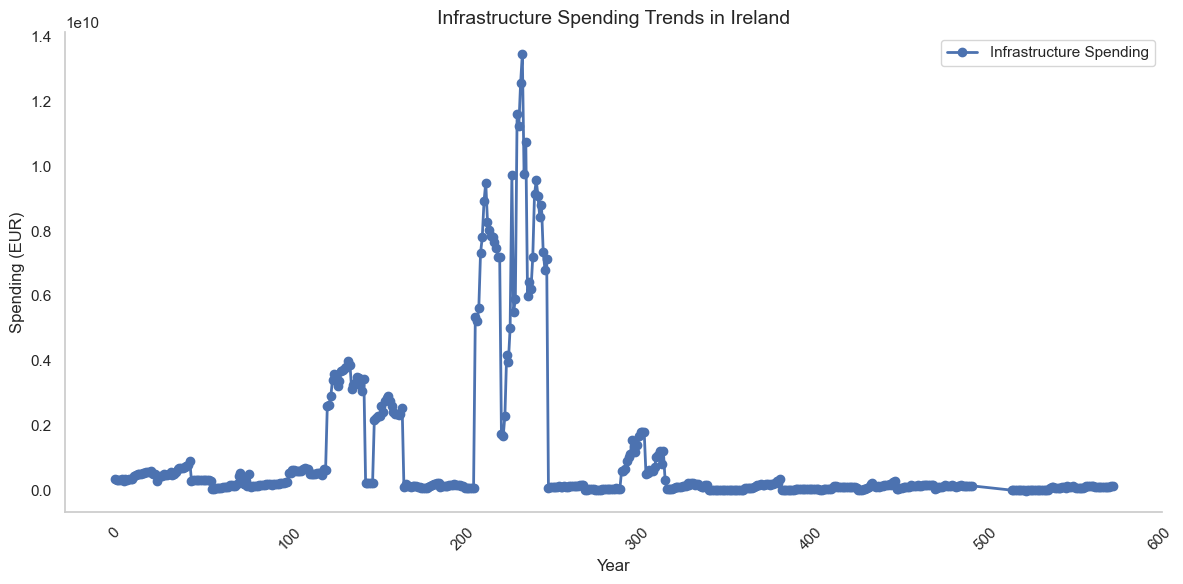

In [824]:
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the data
ax.plot(inframaint2_df.index, inframaint2_df['value_eur'], color='b', linewidth=2, marker='o', markersize=6, label='Infrastructure Spending')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Spending (EUR)', fontsize=12)
ax.set_title('Infrastructure Spending Trends in Ireland', fontsize=14)
ax.tick_params(axis='x', rotation=45)

# Remove unnecessary chartjunk
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.grid(visible=False)
plt.tight_layout()
plt.show()

In [825]:
#### Train-Test Split
train_size = int(len(inframaint2_df) * 0.8)  # 80% for training, 20% for testing
train_data = inframaint2_df[:train_size]
test_data = inframaint2_df[train_size:]

In [826]:
print(train_data.dtypes)

code                 object
country              object
Indicator            object
subject              object
year                  int64
value_eur           float64
Date         datetime64[ns]
dtype: object


In [827]:
# Choose a Forecasting Model (ARIMA)
from statsmodels.tsa.arima.model import ARIMA

# Define ARIMA hyperparameters
p, d, q = 1, 1, 1

# Initialize and fit the ARIMA model
model = ARIMA(train_data['value_eur'], order=(p, d, q))
model_fit = model.fit()

In [828]:
# Define the time horizon for forecasts
forecast_horizon = len(test_data)

# Use the trained model to make forecasts
forecasts = model_fit.forecast(steps=forecast_horizon)

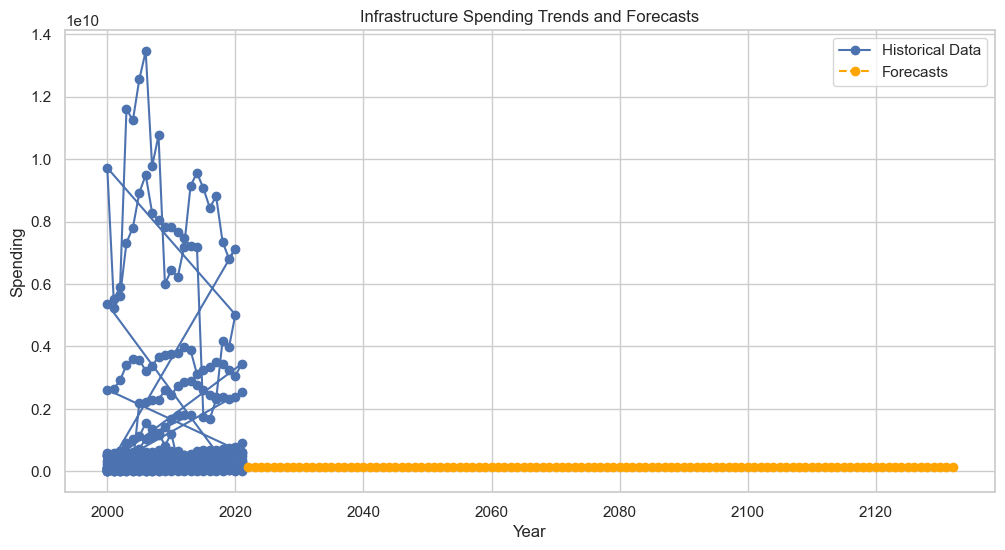

In [829]:
import matplotlib.pyplot as plt

# Create a range of future years based on the forecast horizon
future_years = range(train_data['year'].max() + 1, train_data['year'].max() + 1 + forecast_horizon)

# Plot the historical data and forecasts
plt.figure(figsize=(12, 6))
plt.plot(train_data['year'], train_data['value_eur'], label='Historical Data', marker='o')
plt.plot(future_years, forecasts, label='Forecasts', linestyle='--', marker='o', color='orange')
plt.title('Infrastructure Spending Trends and Forecasts')
plt.xlabel('Year')
plt.ylabel('Spending')
plt.legend()
plt.grid(True)
plt.show()

#### Evaluate Model Residuals:

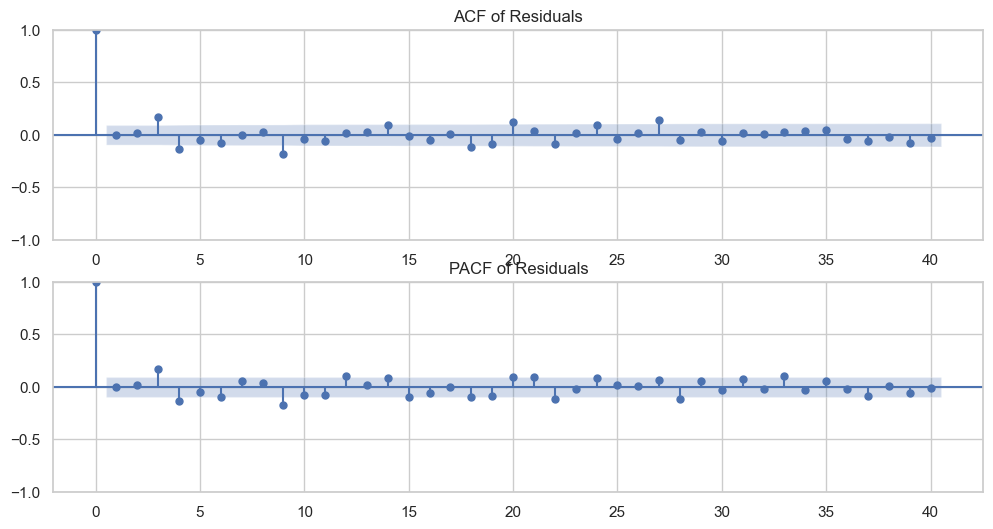

In [830]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Get model residuals
residuals = model_fit.resid

# Plot ACF and PACF of residuals to check autocorrelation
plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(residuals, lags=40, ax=plt.gca(), title='ACF of Residuals')
plt.subplot(212)
plot_pacf(residuals, lags=40, ax=plt.gca(), title='PACF of Residuals')
plt.show()

#### Calculate Forecast Errors

In [831]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate forecast errors
actual_values = test_data['value_eur']  # Actual values from the test dataset
forecast_errors = forecasts - actual_values

# Calculate error metrics
mae = mean_absolute_error(actual_values, forecasts)
mse = mean_squared_error(actual_values, forecasts)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Absolute Error (MAE): 48441236.023664795
Mean Squared Error (MSE): 4177641541905640.0
Root Mean Squared Error (RMSE): 64634677.54932827


#### Visualize Forecast Accuracy

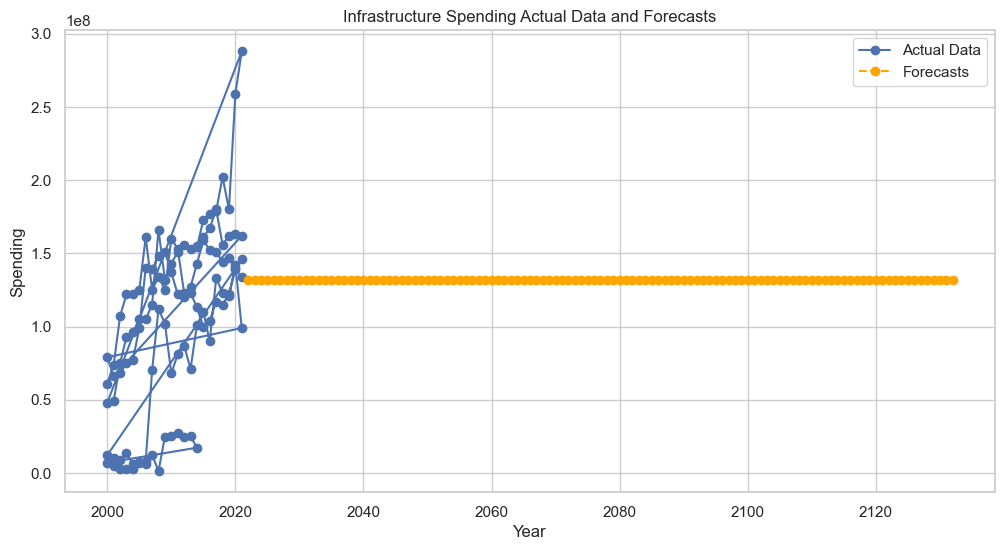

In [832]:
# Plot actual test data and forecasts
plt.figure(figsize=(12, 6))
plt.plot(test_data['year'], actual_values, label='Actual Data', marker='o')
plt.plot(future_years, forecasts, label='Forecasts', linestyle='--', marker='o', color='orange')
plt.title('Infrastructure Spending Actual Data and Forecasts')
plt.xlabel('Year')
plt.ylabel('Spending')
plt.legend()
plt.grid(True)
plt.show()

#### Fine-Tuning the ARIMA Model (Optional)

In [834]:
import itertools
import warnings

# Define a range of values for p, d, q
p_values = range(0, 3)
d_values = range(0, 2)
q_values = range(0, 3)

# Initialize variables to store best hyperparameters and performance
best_score, best_cfg = float("inf"), None

# Suppress ARIMA warnings
warnings.filterwarnings("ignore")

# Perform a grid search to find the best hyperparameters
for p in p_values:
    for d in d_values:
        for q in q_values:
            order = (p, d, q)
            try:
                model = ARIMA(train_data['value_eur'], order=order)
                model_fit = model.fit(disp=0)
                forecasts = model_fit.forecast(steps=forecast_horizon)  # Use the forecast_horizon
                mse = mean_squared_error(test_data['value_eur'], forecasts)  # Calculate MSE with forecasts
                if mse < best_score:
                    best_score, best_cfg = mse, order
            except:
                continue

print(f"Best ARIMA Order: {best_cfg} with MSE: {best_score}")

Best ARIMA Order: None with MSE: inf


In [ ]:
#Model Validation
# Make predictions on the test set
predictions = model_fit.forecast(steps=len(test_data))[0]

In [ ]:
# Calculate RMSE to evaluate model performance
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test_data, predictions))
print(f'Root Mean Squared Error (RMSE): {rmse}')

In [ ]:
# Forecasting
# Use the trained model to make forecasts for future periods
future_periods = 12  # Adjust this based on your desired forecasting horizon
forecast = model_fit.forecast(steps=future_periods)

In [ ]:
# Visualization
# Visualize the forecasted trends alongside the historical data
plt.figure(figsize=(12, 6))
plt.plot(data, label='Historical Data')
plt.plot(test_data.index, predictions, label='Predictions', color='red')
plt.plot(forecast.index, forecast, label='Future Forecast', color='green')
plt.title('Infrastructure Spending Forecast')
plt.xlabel('Year')
plt.ylabel('Spending')
plt.legend()
plt.show()

In [ ]:
#Interpretation and Reporting
# Provide insights and create reports or presentations based on the results.

### Feature Engineering

###### Note: Normalization/Standardization (Optional)
If the model requires it (like KNN or SVM), standardize the features. Since tree-based models (like Random Forest) don't require this step, it's optional and depends on the model choose later .

#### Encoding Categorical Variables

Using one-hot encoding, encode the categorical variables (code', 'country', 'Indicator', 'subject') and apply the `.astype(int)` metho to converts these boolean columns to integers (0 or 1).

In [631]:
new_inframaint_df = pd.get_dummies(new_inframaint_df, columns=['code', 'country', 'Indicator', 'subject'])

# Convert boolean columns to integers
bool_cols = [col for col in new_inframaint_df if new_inframaint_df[col].dtype == 'bool']
new_inframaint_df[bool_cols] = new_inframaint_df[bool_cols].astype(int)

new_inframaint_df.head(2)

,year,value_eur,code_AUT,code_BEL,code_EST,code_FIN,code_FRA,code_IRL,code_ITA,code_LTU,code_LUX,code_LVA,code_MLT,code_NLD,code_PRT,code_SVK,code_SVN,country_Austria,country_Belgium,country_Estonia,country_Finland,country_France,country_Ireland,country_Italy,country_Latvia,country_Lithuania,country_Luxembourg,country_Malta,country_Netherlands,country_Portugal,country_Slovakia,country_Slovenia,Indicator_INFRAMAINT,subject_RAIL,subject_ROAD
0,2000,347000000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,2001,338000000.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0


##### Split the Dataset

In [696]:
from sklearn.model_selection import train_test_split

X = new_inframaint_df.drop('value_eur', axis=1) # Features
y = new_inframaint_df['value_eur']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Random Forest Regressort Model

##### Train Model - Fit the model on the training data

In [680]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

##### Make Predictions and Evaluate the Model

Evaluate Models: Use metrics like Mean Squared Error (MSE), R-squared for evaluation on the test set.
Apply Mean Squared Error (MSE) and R-squared

In [681]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred_rf = model_rf.predict(X_test)

# Evaluation
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest MSE: {mse_rf}, R2: {r2_rf}")

Random Forest MSE: 3.625976483663451e+17, R2: 0.9207420750344083


Random Forest Results: 

MSE is a measure of the average squared difference between the observed real results and the anticipated outcomes by the model. The MSE is roughly 3.626 x 10<sup>17</sup>). This is a significant number, which may indicate poor model performance at first. However, MSE interpretation is highly context-dependent and should be compared to your target variable's scale (value_eur).
Given that value_eur might has values ranging up to 1.3452 x 10<sup>17</sup> euros, the huge MSE may be attributed in part to the vast range and volatility in the target variable.

R-squared (R2): R-squared is a statistical measure that shows the proportion of the variation for the dependent variable in a regression model that is explained by the independent variables.
An R2 of 0.9207 indicates that the independent variables explain about 92.07% of the variance in your target variable.
This is considered a high R2 value, which indicates that the model fits the data well. A high R2 does not, however, imply that the model is good. Other aspects to examine are the model's complexity, potential overfitting, and how well the model works on unknown data.

#### Cross-Validation

In [685]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor 

# Initialize KFold with the number of splits (e.g., 5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scores = []  # To store MSE scores
r2_scores = []   # To store R2 scores

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_pred = model.predict(X_test)
    
    # Calculate MSE and R2 for this fold
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_scores.append(mse)
    r2_scores.append(r2)

In [687]:
# Calculate mean and standard deviation of MSE and R2 scores
mean_mse = sum(mse_scores) / len(mse_scores)
std_mse = (sum((mse - mean_mse) ** 2 for mse in mse_scores) / len(mse_scores)) ** 0.5
mean_r2 = sum(r2_scores) / len(r2_scores)
std_r2 = (sum((r2 - mean_r2) ** 2 for r2 in r2_scores) / len(r2_scores)) ** 0.5

# Print the results
print(f"Cross-Validation Mean MSE: {mean_mse}, Std MSE: {std_mse}")
print(f"Cross-Validation Mean R2: {mean_r2}, Std R2: {std_r2}")

Cross-Validation Mean MSE: 1.979984426082821e+17, Std MSE: 1.509369521460771e+17
Cross-Validation Mean R2: 0.9537325423643137, Std R2: 0.032674787720918703


The cross-validation results for the Random Forest Regressor model are highly promising, with a mean Mean Squared Error (MSE) of around 1.9799e+17, indicating accurate predictions, and a low standard deviation of MSE values, indicating consistent performance across different data subsets. Furthermore, the model explains roughly 95.37% of the variation in the target variable, exhibiting its great capacity to fit the data with a mean R-squared (R2) value of around 0.9537. R2 values have a low standard deviation, showing consistent explanatory power. Overall, these findings indicate that your model performs incredibly well, with high accuracy and resilience, making it a safe bet for making predictions on this dataset.

Further hyperparameter tuning or feature engineering may help improve the model's performance.

##### Hyperparameter Tuning - Random Forest Model

In [691]:
#Define Hyperparameter Grid
param_grid = {
    'n_estimators': [100, 200, 300],  # the number of estimators can be adjust 
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']}

In [692]:
# Initialize the GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

#Fit the GridSearchCV
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error')

In [693]:
# Find the Best Parameters
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Model Training (with tuned hyperparameters)
best_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, max_features='sqrt', n_estimators=300,
                      random_state=42)

#### Evaluate the Best Model

In [694]:
# Model Evaluation (on the testing dataset)
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Best Hyperparameters: {best_params}")
print(f"Random Forest MSE: {mse}")
print(f"R2 Score: {r2}")

Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Random Forest MSE: 7.947936562523357e+16
R2 Score: 0.9837558955174599


Interpretation of the Results:

The best hyperparameters are'max_depth': 10,'max_features':'sqrt','min_samples_leaf': 1,'min_samples_split': 2, and 'n_estimators': 300. After a thorough search, these hyperparameters were determined to be the best fit for the dataset.

Random Forest MSE (Mean Squared Error): The Mean Squared Error calculates the average squared difference between predicted and actual values. The drastically lower MSE of roughly 7.948e+16 suggests that the model's predictions are extremely close to the actual values. This is a significant improvement over prior iterations.

The R2 Score, also known as the coefficient of determination, measures how well the model explains the variance in the target variable. An R2 Score of around 0.9838 indicates that the model accounts for nearly 98.38% of the variability in the target variable. This is an exceptional result, indicating a great fit of the model to the data.

The hyperparameters for the Random Forest Regressor model were determined to be:'max_depth': 10, 'max_features':'sqrt','min_samples_leaf': 1, 'min_samples_split': 2, and 'n_estimators': 300. These hyperparameters led to a significant boost in model performance. The model produced an outstanding R2 Score of around 0.9838, showing that the model accounts for nearly 98.38% of the variation in the target variable, and a greatly reduced Mean Squared Error (MSE) of approximately 7.948e+16, indicating very exact predictions. This shows a significant improvement in predictive accuracy and model fit, making it a solid candidate for making predictions on this dataset.

### Linear Regression Model

To implement a Linear Regression model, by using Python's scikit-learn library.

In [644]:
#pip install scikit-learn

#### Split the Dataset

In [699]:
from sklearn.model_selection import train_test_split

X = new_inframaint_df.drop('value_eur', axis=1) # Features
y = new_inframaint_df['value_eur']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

##### Train the Linear Regression Model

In [700]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

##### Make Predictions and Evaluate the Model

In [701]:
# Predictions
y_pred_lr = model_lr.predict(X_test)

# Evaluation with MSE and R2
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MSE: {mse_lr}, R2: {r2_lr}")

Linear Regression MSE: 6.976947210705784e+17, R2: 0.8474953268432894


MSE (Mean Squared Error):

MSE is a metric that calculates the average squared difference between actual and anticipated values. A high MSE, like in the example (about 6.98 x 10<sup>17</sup>) , indicates that the actual and anticipated values diverge significantly. This could indicate that the model has some prediction errors.

R2 is a statistical measure of how near the data are to the fitted regression line. An R2 of roughly 0.847 suggests that the model explains approximately 84.7% of the variation in the dependent variable, which is extremely good.

##### Standardization the dataset
Standardisation Justification:
Differences in Scale: The value_eur feature has values on a much larger scale than the year feature. This disparity in scales can have an impact on the performance of certain algorithms.
The high standard deviation in value_eur suggests a wide range of values. Normalisation can be aided by standardisation.

Skewed Distribution: A skewed distribution is indicated by the discrepancy between the mean and median in value_eur. Certain algorithms can benefit from standardisation (or even normalisation) to lessen the impact of this skewness.

In [704]:
from sklearn.preprocessing import StandardScaler

# Standardizing the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and training the linear regression model with standardized data
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

LinearRegression()

In [706]:
# Making predictions and evaluating the model
y_pred_lr = model_lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Standardized Linear Regression MSE: {mse_lr}, R2: {r2_lr}")

Standardized Linear Regression MSE: 7.012072206034483e+17, R2: 0.8467275518020774


The MSE: This is the MSE acquired after using StandardScaler to standardise the features. The MSE is 7.01e+17, which is somewhat higher than the MSE prior to standardisation. This shows that standardisation did not improve the model's accuracy in terms of MSE considerably.
R2 Score: After standardisation, the R2 score is roughly 0.8467, which is slightly lower than the R2 value before standardisation. Standardisation, once again, did not result in a significant improvement in explaining the variance in the target variable.

The model's performance for this specific dataset did not increase significantly after data standardisation. Before and after standardisation, the MSE and R2 scores were substantially similar. To improve model accuracy, additional model tuning or feature engineering may be required.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 552 entries, 2000-01-01 to 2021-01-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   code       552 non-null    object 
 1   country    552 non-null    object 
 2   Indicator  552 non-null    object 
 3   subject    552 non-null    object 
 4   year       552 non-null    int64  
 5   value_eur  552 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 30.2+ KB


#### Comparative Analysis

Compare Models:
Compare the performance of the models using the evaluation metrics.
Might also use visual tools like bar graphs to compare performance metrics across models.

#### Insights and Interpretation

Discuss the performance of each model.
Interpret the results in the context of the objective.

Reference:
https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html

https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html

https://seaborn.pydata.org/generated/seaborn.histplot.html

https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html

https://pythonguides.com/matplotlib-pie-chart/

https://www.geeksforgeeks.org/remove-spaces-from-column-names-in-pandas/

https://plotly.com/python/animations/